In [ ]:
# Import libraries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print(f"✅ Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"YFinance version: {yf.__version__}")

✅ Libraries imported successfully!
Pandas version: 3.0.3
YFinance version: 1.5.1


In [ ]:
# Set date range
start_date = '2015-01-01'
end_date = '2026-06-30'

# Define tickers
tickers = ['TSLA', 'BND', 'SPY']

print(f"Downloading data from {start_date} to {end_date}")
print(f"Assets: {tickers}")
print("-" * 50)

# Download data for each ticker
data = {}
for ticker in tickers:
    print(f"⬇️  Downloading {ticker}...")
    try:
        data[ticker] = yf.download(ticker, start=start_date, end=end_date, progress=False)
        print(f"   ✅ {ticker}: {len(data[ticker])} rows downloaded")
    except Exception as e:
        print(f"   ❌ Error downloading {ticker}: {e}")

print("-" * 50)
print("✅ Data download complete!")


Assets: ['TSLA', 'BND', 'SPY']
--------------------------------------------------
⬇️  Downloading TSLA...
   ✅ TSLA: 2888 rows downloaded
⬇️  Downloading BND...
   ✅ BND: 2888 rows downloaded
⬇️  Downloading SPY...
   ✅ SPY: 2888 rows downloaded
--------------------------------------------------
✅ Data download complete!


In [3]:
# Check each dataset
for ticker in tickers:
    print(f"\n{'='*50}")
    print(f"📊 {ticker} Data Overview")
    print(f"{'='*50}")
    print(f"Shape: {data[ticker].shape}")
    print(f"Columns: {data[ticker].columns.tolist()}")
    print(f"\nFirst 5 rows:")
    print(data[ticker].head())
    print(f"\nLast 5 rows:")
    print(data[ticker].tail())
    print(f"\nData types:")
    print(data[ticker].dtypes)
    print(f"\nMissing values:")
    print(data[ticker].isnull().sum())


📊 TSLA Data Overview
Shape: (2888, 5)
Columns: [('Close', 'TSLA'), ('High', 'TSLA'), ('Low', 'TSLA'), ('Open', 'TSLA'), ('Volume', 'TSLA')]

First 5 rows:
Price           Close       High        Low       Open    Volume
Ticker           TSLA       TSLA       TSLA       TSLA      TSLA
Date                                                            
2015-01-02  14.620667  14.883333  14.217333  14.858000  71466000
2015-01-05  14.006000  14.433333  13.810667  14.303333  80527500
2015-01-06  14.085333  14.280000  13.614000  14.004000  93928500
2015-01-07  14.063333  14.318667  13.985333  14.223333  44526000
2015-01-08  14.041333  14.253333  14.000667  14.187333  51637500

Last 5 rows:
Price            Close        High         Low        Open    Volume
Ticker            TSLA        TSLA        TSLA        TSLA      TSLA
Date                                                                
2026-06-23  381.609985  392.869995  379.059998  392.609985  50420200
2026-06-24  375.529999  384.579987

In [10]:
# Save each asset's data to CSV
import os

# Create the directory if it doesn't exist
os.makedirs('data/processed', exist_ok=True)
print("✅ Directory 'data/processed/' created successfully!")
for ticker in tickers:
    filename = f'data/processed/{ticker}_raw.csv'
    data[ticker].to_csv(filename)
    print(f"✅ Saved {ticker} data to {filename}")

# Show what was saved
print("\n📁 Files saved:")
import os
files = os.listdir('data/processed/')
for f in files:
    print(f"   - {f}")

✅ Directory 'data/processed/' created successfully!
✅ Saved TSLA data to data/processed/TSLA_raw.csv
✅ Saved BND data to data/processed/BND_raw.csv
✅ Saved SPY data to data/processed/SPY_raw.csv

📁 Files saved:
   - BND_raw.csv
   - SPY_raw.csv
   - TSLA_raw.csv


In [11]:
# Extract 'Adj Close' (or 'Close' if 'Adj Close' doesn't exist)
adj_close = pd.DataFrame()

for ticker in tickers:
    # Check if 'Adj Close' exists, if not use 'Close'
    if 'Adj Close' in data[ticker].columns:
        adj_close[ticker] = data[ticker]['Adj Close']
        print(f"✅ {ticker}: Using 'Adj Close' column")
    elif 'Close' in data[ticker].columns:
        adj_close[ticker] = data[ticker]['Close']
        print(f"✅ {ticker}: Using 'Close' column (fallback)")
    else:
        print(f"❌ {ticker}: No price column found!")
        print(f"   Available columns: {data[ticker].columns.tolist()}")

print("\n📊 Combined Data:")
print(adj_close.head())

✅ TSLA: Using 'Close' column (fallback)
✅ BND: Using 'Close' column (fallback)
✅ SPY: Using 'Close' column (fallback)

📊 Combined Data:
                 TSLA        BND         SPY
Date                                        
2015-01-02  14.620667  59.405411  169.687805
2015-01-05  14.006000  59.577930  166.623352
2015-01-06  14.085333  59.750401  165.053894
2015-01-07  14.063333  59.786343  167.110718
2015-01-08  14.041333  59.692944  170.076035


In [12]:
# Check column names for each ticker
for ticker in tickers:
    print(f"\n{ticker} columns:")
    print(data[ticker].columns.tolist())


TSLA columns:
[('Close', 'TSLA'), ('High', 'TSLA'), ('Low', 'TSLA'), ('Open', 'TSLA'), ('Volume', 'TSLA')]

BND columns:
[('Close', 'BND'), ('High', 'BND'), ('Low', 'BND'), ('Open', 'BND'), ('Volume', 'BND')]

SPY columns:
[('Close', 'SPY'), ('High', 'SPY'), ('Low', 'SPY'), ('Open', 'SPY'), ('Volume', 'SPY')]


In [13]:
# Extract closing prices from MultiIndex columns
adj_close = pd.DataFrame()

for ticker in tickers:
    # Access the 'Close' column for this specific ticker using the tuple
    adj_close[ticker] = data[ticker][('Close', ticker)]
    print(f"✅ {ticker}: Extracted Close price")

print("\n📊 Combined Adjusted Close Data:")
print("="*50)
print(f"Shape: {adj_close.shape}")
print(f"Date range: {adj_close.index.min()} to {adj_close.index.max()}")
print(f"\nFirst 5 rows:")
print(adj_close.head())
print(f"\nLast 5 rows:")
print(adj_close.tail())
print(f"\nMissing values:")
print(adj_close.isnull().sum())

# Save combined data
adj_close.to_csv('data/processed/combined_adj_close.csv')
print("\n✅ Saved combined data to data/processed/combined_adj_close.csv")

✅ TSLA: Extracted Close price
✅ BND: Extracted Close price
✅ SPY: Extracted Close price

📊 Combined Adjusted Close Data:
Shape: (2888, 3)
Date range: 2015-01-02 00:00:00 to 2026-06-29 00:00:00

First 5 rows:
                 TSLA        BND         SPY
Date                                        
2015-01-02  14.620667  59.405411  169.687805
2015-01-05  14.006000  59.577930  166.623352
2015-01-06  14.085333  59.750401  165.053894
2015-01-07  14.063333  59.786343  167.110718
2015-01-08  14.041333  59.692944  170.076035

Last 5 rows:
                  TSLA        BND         SPY
Date                                         
2026-06-23  381.609985  72.976631  733.580017
2026-06-24  375.529999  73.305534  733.239990
2026-06-25  375.119995  73.355370  734.299988
2026-06-26  379.709991  73.425133  728.989990
2026-06-29  411.839996  73.465004  741.000000

Missing values:
TSLA    0
BND     0
SPY     0
dtype: int64

✅ Saved combined data to data/processed/combined_adj_close.csv


In [2]:
# Import libraries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [3]:
# Set date range
start_date = '2015-01-01'
end_date = '2026-06-30'

# Define tickers
tickers = ['TSLA', 'BND', 'SPY']

print(f"Downloading data from {start_date} to {end_date}")
print(f"Assets: {tickers}")
print("-" * 50)

# Download data for each ticker
data = {}
for ticker in tickers:
    print(f"⬇️  Downloading {ticker}...")
    try:
        data[ticker] = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True, progress=False)
        print(f"   ✅ {ticker}: {len(data[ticker])} rows downloaded")
    except Exception as e:
        print(f"   ❌ Error downloading {ticker}: {e}")

print("-" * 50)
print("✅ Data download complete!")

Assets: ['TSLA', 'BND', 'SPY']
--------------------------------------------------
⬇️  Downloading TSLA...
   ✅ TSLA: 2888 rows downloaded
⬇️  Downloading BND...
   ✅ BND: 2888 rows downloaded
⬇️  Downloading SPY...
   ✅ SPY: 2888 rows downloaded
--------------------------------------------------
✅ Data download complete!


In [4]:
# Check column names for each ticker
for ticker in tickers:
    print(f"\n{ticker} columns:")
    print(data[ticker].columns.tolist())


TSLA columns:
[('Close', 'TSLA'), ('High', 'TSLA'), ('Low', 'TSLA'), ('Open', 'TSLA'), ('Volume', 'TSLA')]

BND columns:
[('Close', 'BND'), ('High', 'BND'), ('Low', 'BND'), ('Open', 'BND'), ('Volume', 'BND')]

SPY columns:
[('Close', 'SPY'), ('High', 'SPY'), ('Low', 'SPY'), ('Open', 'SPY'), ('Volume', 'SPY')]


In [5]:
# Extract closing prices and create combined DataFrame
adj_close = pd.DataFrame()

for ticker in tickers:
    # Access the 'Close' column for this specific ticker
    adj_close[ticker] = data[ticker][('Close', ticker)]
    print(f"✅ {ticker}: Extracted Close price")

print("\n📊 Combined Adjusted Close Data:")
print("="*50)
print(f"Shape: {adj_close.shape}")
print(f"Date range: {adj_close.index.min()} to {adj_close.index.max()}")
print(f"\nFirst 5 rows:")
print(adj_close.head())
print(f"\nLast 5 rows:")
print(adj_close.tail())

✅ TSLA: Extracted Close price
✅ BND: Extracted Close price
✅ SPY: Extracted Close price

📊 Combined Adjusted Close Data:
Shape: (2888, 3)
Date range: 2015-01-02 00:00:00 to 2026-06-29 00:00:00

First 5 rows:
                 TSLA        BND         SPY
Date                                        
2015-01-02  14.620667  59.405373  169.687775
2015-01-05  14.006000  59.577904  166.623398
2015-01-06  14.085333  59.750362  165.053879
2015-01-07  14.063333  59.786331  167.110672
2015-01-08  14.041333  59.692917  170.076050

Last 5 rows:
                  TSLA        BND         SPY
Date                                         
2026-06-23  381.609985  72.976631  733.580017
2026-06-24  375.529999  73.305534  733.239990
2026-06-25  375.119995  73.355370  734.299988
2026-06-26  379.709991  73.425133  728.989990
2026-06-29  411.839996  73.465004  741.000000


In [6]:
import os

# Create directory
os.makedirs('data/processed', exist_ok=True)
print("✅ Directory created: data/processed/")

# Save raw data
for ticker in tickers:
    filename = f'data/processed/{ticker}_raw.csv'
    data[ticker].to_csv(filename)
    print(f"✅ Saved {ticker} to {filename}")

# Save combined data
adj_close.to_csv('data/processed/combined_adj_close.csv')
print("✅ Saved combined data to data/processed/combined_adj_close.csv")

✅ Directory created: data/processed/
✅ Saved TSLA to data/processed/TSLA_raw.csv
✅ Saved BND to data/processed/BND_raw.csv
✅ Saved SPY to data/processed/SPY_raw.csv
✅ Saved combined data to data/processed/combined_adj_close.csv


In [7]:
# Handle missing values
print("🛠️  Handling Missing Values")
print("="*50)

if adj_close.isnull().sum().sum() > 0:
    print(f"Found {adj_close.isnull().sum().sum()} missing values total")
    
    # Forward fill first, then backward fill
    adj_close_clean = adj_close.fillna(method='ffill').fillna(method='bfill')
    
    # Check if any remain
    if adj_close_clean.isnull().sum().sum() > 0:
        print("⚠️  Some missing values remain. Removing rows with NaN...")
        adj_close_clean = adj_close_clean.dropna()
    
    print(f"✅ Missing values after cleaning: {adj_close_clean.isnull().sum().sum()}")
else:
    adj_close_clean = adj_close.copy()
    print("✅ No missing values found!")

# Save cleaned data
adj_close_clean.to_csv('data/processed/combined_adj_close_clean.csv')
print("✅ Saved cleaned data to data/processed/combined_adj_close_clean.csv")

# Show sample of cleaned data
print("\n📊 Cleaned Data Sample:")
print(adj_close_clean.head())


🛠️  Handling Missing Values
✅ No missing values found!
✅ Saved cleaned data to data/processed/combined_adj_close_clean.csv

📊 Cleaned Data Sample:
                 TSLA        BND         SPY
Date                                        
2015-01-02  14.620667  59.405373  169.687775
2015-01-05  14.006000  59.577904  166.623398
2015-01-06  14.085333  59.750362  165.053879
2015-01-07  14.063333  59.786331  167.110672
2015-01-08  14.041333  59.692917  170.076050


In [8]:
# Show all files
print("\n📁 Files in data/processed/:")
print("-" * 40)
files = os.listdir('data/processed/')
for file in files:
    size = os.path.getsize(f'data/processed/{file}')
    print(f"   📄 {file} ({size:,} bytes)")

print("\n✅ ALL DATA SAVED SUCCESSFULLY!")


📁 Files in data/processed/:
----------------------------------------
   📄 BND_raw.csv (265,599 bytes)
   📄 combined_adj_close.csv (191,440 bytes)
   📄 combined_adj_close_clean.csv (191,440 bytes)
   📄 SPY_raw.csv (272,969 bytes)
   📄 TSLA_raw.csv (269,166 bytes)

✅ ALL DATA SAVED SUCCESSFULLY!


In [9]:
# Data Quality Check
print("🔍 Data Quality Check")
print("="*50)

print("1. Missing Values:")
missing = adj_close_clean.isnull().sum()
for ticker in tickers:
    print(f"   {ticker}: {missing[ticker]} missing")

print("\n2. Data Types:")
print(adj_close_clean.dtypes)

print("\n3. Basic Statistics:")
print(adj_close_clean.describe())

print("\n4. Date Range:")
print(f"   Start: {adj_close_clean.index.min()}")
print(f"   End: {adj_close_clean.index.max()}")
print(f"   Total trading days: {len(adj_close_clean)}")


🔍 Data Quality Check
1. Missing Values:
   TSLA: 0 missing
   BND: 0 missing
   SPY: 0 missing

2. Data Types:
TSLA    float64
BND     float64
SPY     float64
dtype: object

3. Basic Statistics:
              TSLA          BND          SPY
count  2888.000000  2888.000000  2888.000000
mean    148.773923    66.503053   351.505532
std     138.895957     4.713607   155.443934
min       9.578000    58.729210   154.161636
25%      18.393499    62.478091   223.546799
50%     133.437668    65.728382   312.817902
75%     251.925831    70.689146   432.806808
max     489.880005    74.832947   757.618225

4. Date Range:
   Start: 2015-01-02 00:00:00
   End: 2026-06-29 00:00:00
   Total trading days: 2888


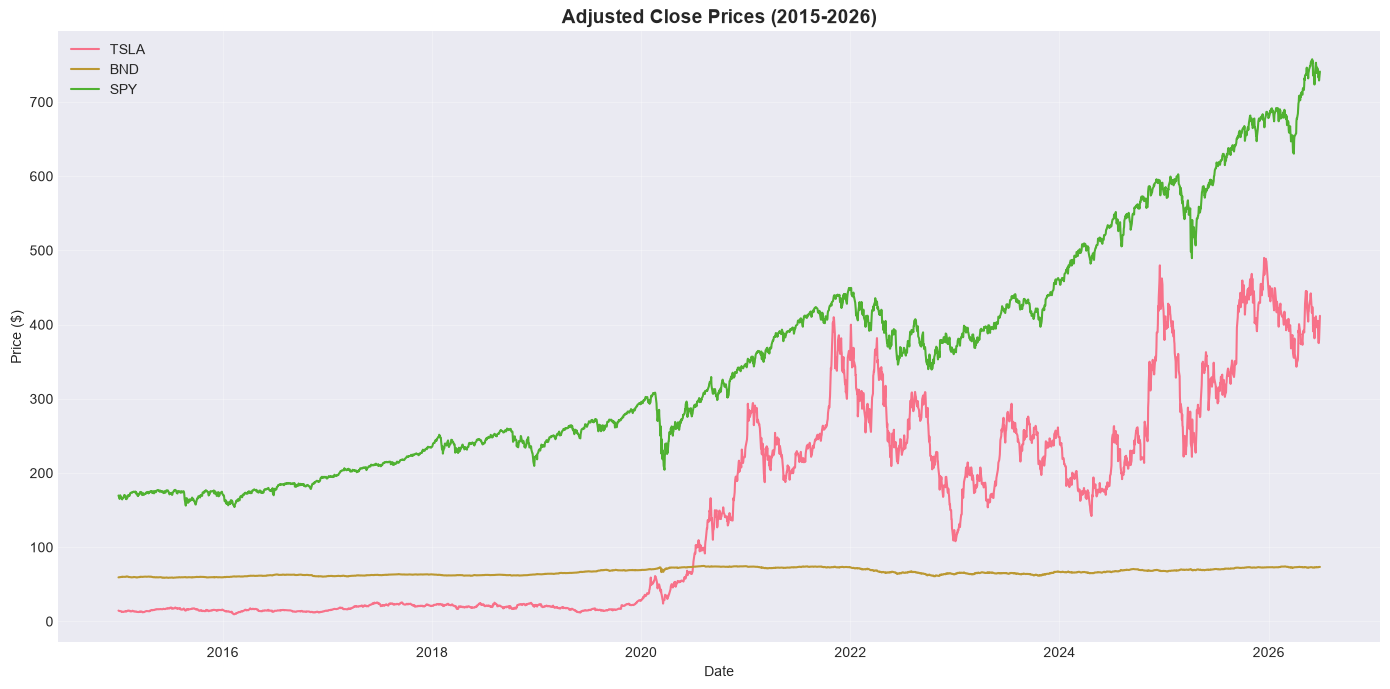

✅ Plot saved to data/processed/closing_prices_plot.png


In [10]:
# Plot the closing prices
fig, ax = plt.subplots(figsize=(14, 7))

for ticker in tickers:
    ax.plot(adj_close_clean.index, adj_close_clean[ticker], label=ticker, linewidth=1.5)

ax.set_title('Adjusted Close Prices (2015-2026)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price ($)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('data/processed/closing_prices_plot.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Plot saved to data/processed/closing_prices_plot.png")

In [11]:
# Data Integrity Checks
print("🔍 Data Integrity Checks")
print("="*60)

# 1. Check data types
print("\n1. Data Types:")
print(adj_close_clean.dtypes)

# 2. Check for duplicates
print("\n2. Duplicate Check:")
duplicates = adj_close_clean.index.duplicated().sum()
print(f"   Duplicate dates: {duplicates}")

# 3. Check date range
print("\n3. Date Range:")
print(f"   Start: {adj_close_clean.index.min()}")
print(f"   End: {adj_close_clean.index.max()}")
print(f"   Total trading days: {len(adj_close_clean)}")

# 4. Check for missing dates (business days)
print("\n4. Missing Trading Days:")
expected_dates = pd.date_range(start=adj_close_clean.index.min(), 
                              end=adj_close_clean.index.max(), 
                              freq='B')  # Business days
actual_dates = adj_close_clean.index
missing_dates = expected_dates.difference(actual_dates)

print(f"   Expected trading days: {len(expected_dates)}")
print(f"   Actual trading days: {len(actual_dates)}")
print(f"   Missing trading days: {len(missing_dates)}")

if len(missing_dates) > 0:
    print(f"   First 5 missing dates: {missing_dates[:5].tolist()}")

# 5. Check for outliers (price)
print("\n5. Price Range Check:")
for ticker in tickers:
    print(f"   {ticker}:")
    print(f"      Min: ${adj_close_clean[ticker].min():.2f}")
    print(f"      Max: ${adj_close_clean[ticker].max():.2f}")
    print(f"      Mean: ${adj_close_clean[ticker].mean():.2f}")

# 6. Check for zero or negative prices
print("\n6. Price Validity Check:")
for ticker in tickers:
    negative_prices = (adj_close_clean[ticker] <= 0).sum()
    if negative_prices > 0:
        print(f"   ⚠️  {ticker}: {negative_prices} zero/negative prices found")
    else:
        print(f"   ✅ {ticker}: All prices are positive")

# 7. Data completeness check
print("\n7. Data Completeness:")
for ticker in tickers:
    completeness = (1 - adj_close_clean[ticker].isnull().sum() / len(adj_close_clean)) * 100
    print(f"   {ticker}: {completeness:.2f}% complete")

print("\n" + "="*60)
print("✅ Data Integrity Checks Complete!")

🔍 Data Integrity Checks

1. Data Types:
TSLA    float64
BND     float64
SPY     float64
dtype: object

2. Duplicate Check:
   Duplicate dates: 0

3. Date Range:
   Start: 2015-01-02 00:00:00
   End: 2026-06-29 00:00:00
   Total trading days: 2888

4. Missing Trading Days:
   Expected trading days: 2997
   Actual trading days: 2888
   Missing trading days: 109
   First 5 missing dates: [Timestamp('2015-01-19 00:00:00'), Timestamp('2015-02-16 00:00:00'), Timestamp('2015-04-03 00:00:00'), Timestamp('2015-05-25 00:00:00'), Timestamp('2015-07-03 00:00:00')]

5. Price Range Check:
   TSLA:
      Min: $9.58
      Max: $489.88
      Mean: $148.77
   BND:
      Min: $58.73
      Max: $74.83
      Mean: $66.50
   SPY:
      Min: $154.16
      Max: $757.62
      Mean: $351.51

6. Price Validity Check:
   ✅ TSLA: All prices are positive
   ✅ BND: All prices are positive
   ✅ SPY: All prices are positive

7. Data Completeness:
   TSLA: 100.00% complete
   BND: 100.00% complete
   SPY: 100.00% compl

In [12]:
# Create a summary DataFrame
integrity_summary = pd.DataFrame({
    'Ticker': tickers,
    'Start_Price': [adj_close_clean[ticker].iloc[0] for ticker in tickers],
    'End_Price': [adj_close_clean[ticker].iloc[-1] for ticker in tickers],
    'Min_Price': [adj_close_clean[ticker].min() for ticker in tickers],
    'Max_Price': [adj_close_clean[ticker].max() for ticker in tickers],
    'Mean_Price': [adj_close_clean[ticker].mean() for ticker in tickers],
    'Total_Change': [((adj_close_clean[ticker].iloc[-1] / adj_close_clean[ticker].iloc[0]) - 1) * 100 for ticker in tickers]
})

print("📊 Price Summary Table:")
print("="*60)
print(integrity_summary.to_string(index=False))

# Save to CSV
integrity_summary.to_csv('data/processed/price_summary.csv')
print("\n✅ Price summary saved to data/processed/price_summary.csv")

📊 Price Summary Table:
Ticker  Start_Price  End_Price  Min_Price  Max_Price  Mean_Price  Total_Change
  TSLA    14.620667 411.839996   9.578000 489.880005  148.773923   2716.834440
   BND    59.405373  73.465004  58.729210  74.832947   66.503053     23.667272
   SPY   169.687775 741.000000 154.161636 757.618225  351.505532    336.684376

✅ Price summary saved to data/processed/price_summary.csv


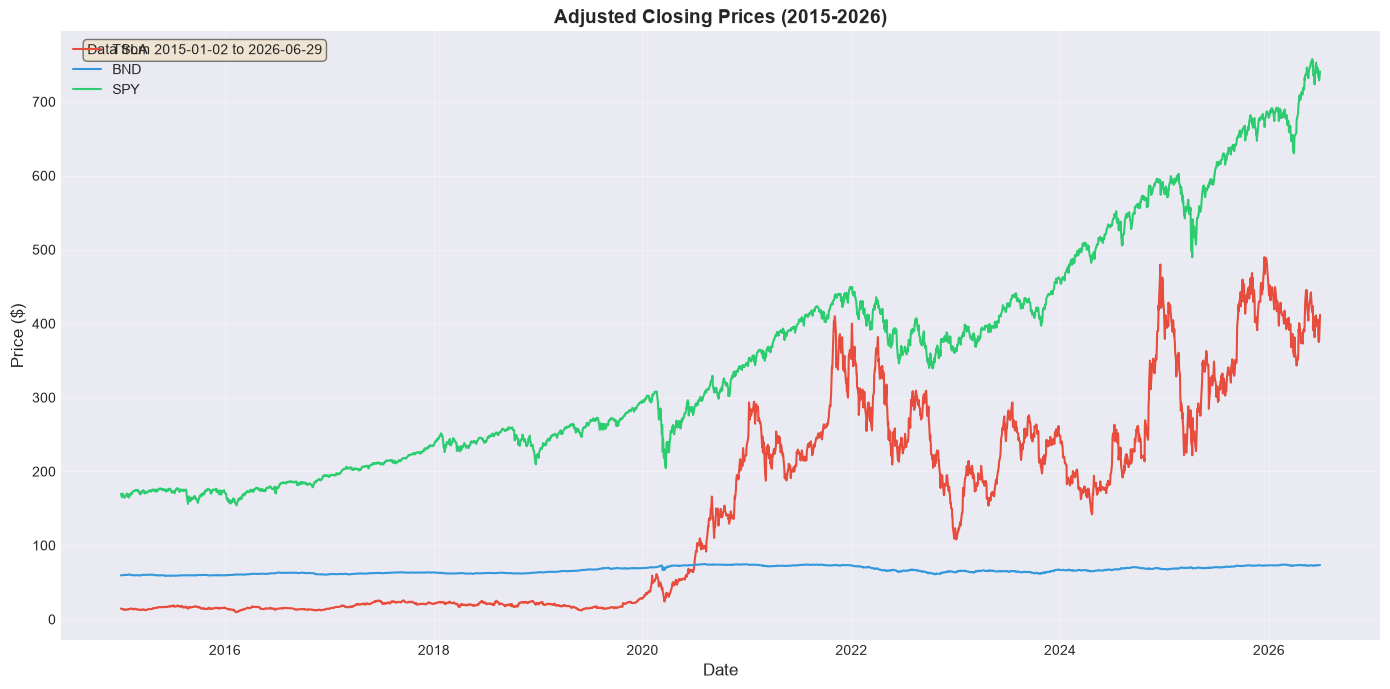

✅ Adjusted closing prices plot saved to data/processed/adjusted_closing_prices.png


In [13]:
# Plot adjusted closing prices
fig, ax = plt.subplots(figsize=(14, 7))

colors = ['#e74c3c', '#3498db', '#2ecc71']  # Red, Blue, Green

for i, ticker in enumerate(tickers):
    ax.plot(adj_close_clean.index, adj_close_clean[ticker], 
            label=f'{ticker}', linewidth=1.5, color=colors[i])

ax.set_title('Adjusted Closing Prices (2015-2026)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price ($)', fontsize=12)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

# Add some annotations
ax.text(0.02, 0.98, f'Data from {adj_close_clean.index.min().strftime("%Y-%m-%d")} to {adj_close_clean.index.max().strftime("%Y-%m-%d")}',
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('data/processed/adjusted_closing_prices.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Adjusted closing prices plot saved to data/processed/adjusted_closing_prices.png")

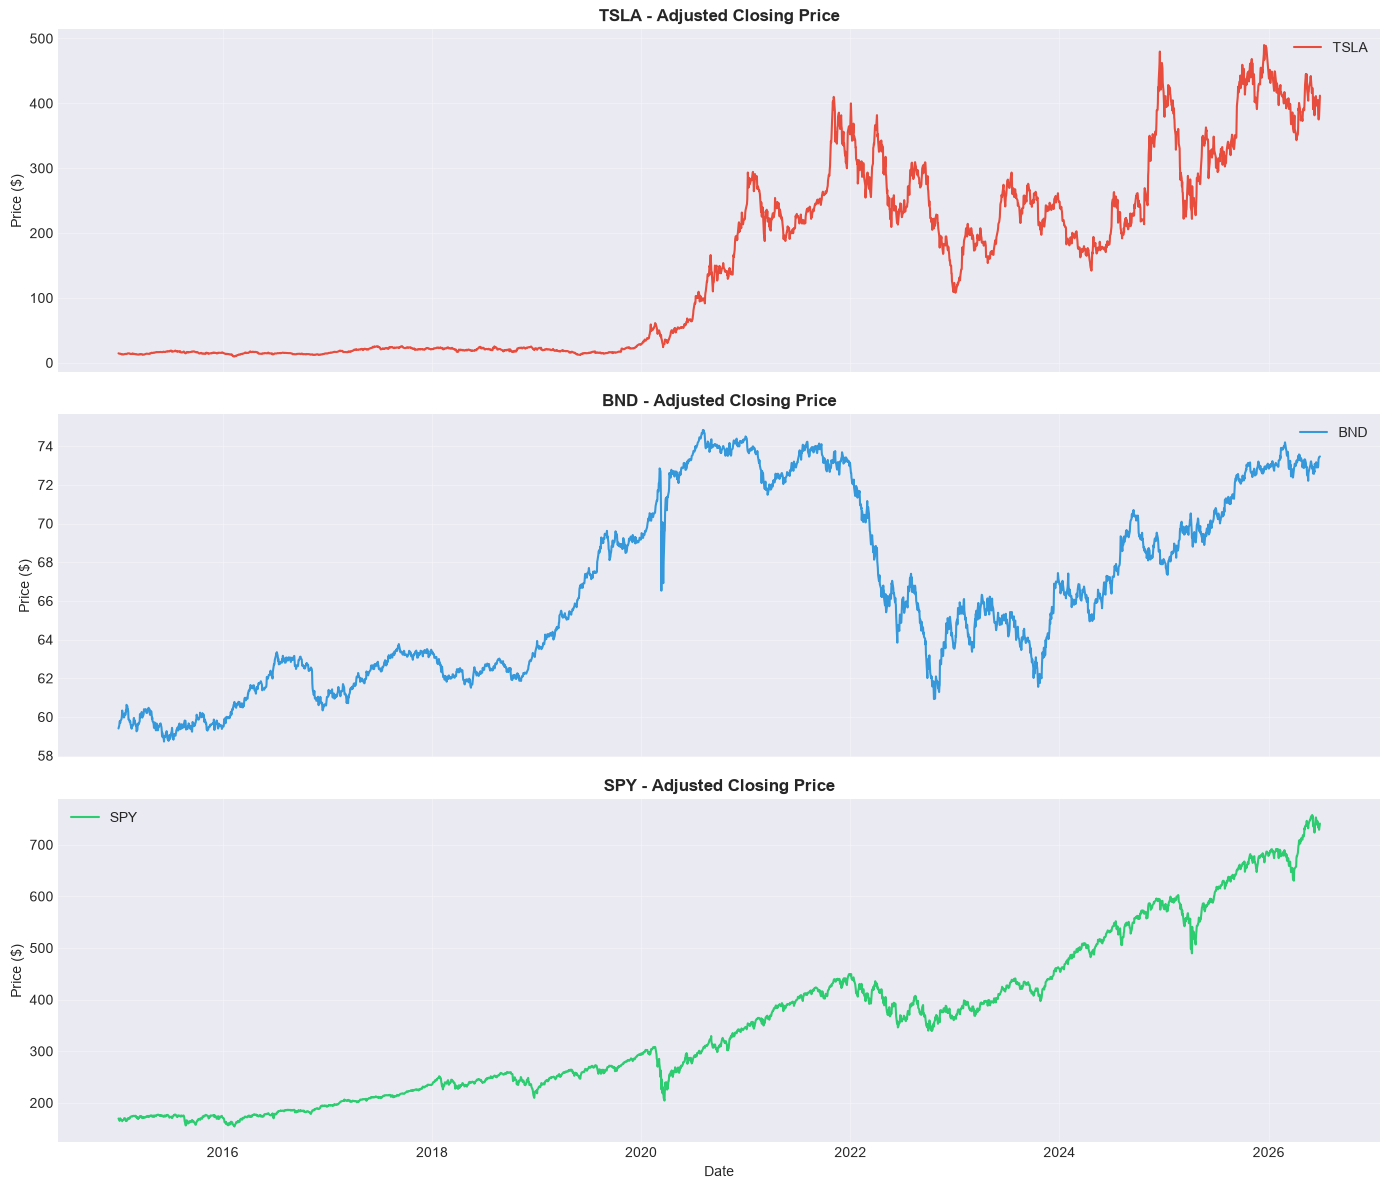

✅ Subplots saved to data/processed/adjusted_closing_prices_subplots.png


In [14]:
# Plot each asset separately with subplots
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

for i, ticker in enumerate(tickers):
    axes[i].plot(adj_close_clean.index, adj_close_clean[ticker], 
                color=colors[i], linewidth=1.5)
    axes[i].set_title(f'{ticker} - Adjusted Closing Price', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Price ($)')
    axes[i].grid(True, alpha=0.3)
    axes[i].legend([ticker])

plt.xlabel('Date')
plt.tight_layout()
plt.savefig('data/processed/adjusted_closing_prices_subplots.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Subplots saved to data/processed/adjusted_closing_prices_subplots.png")

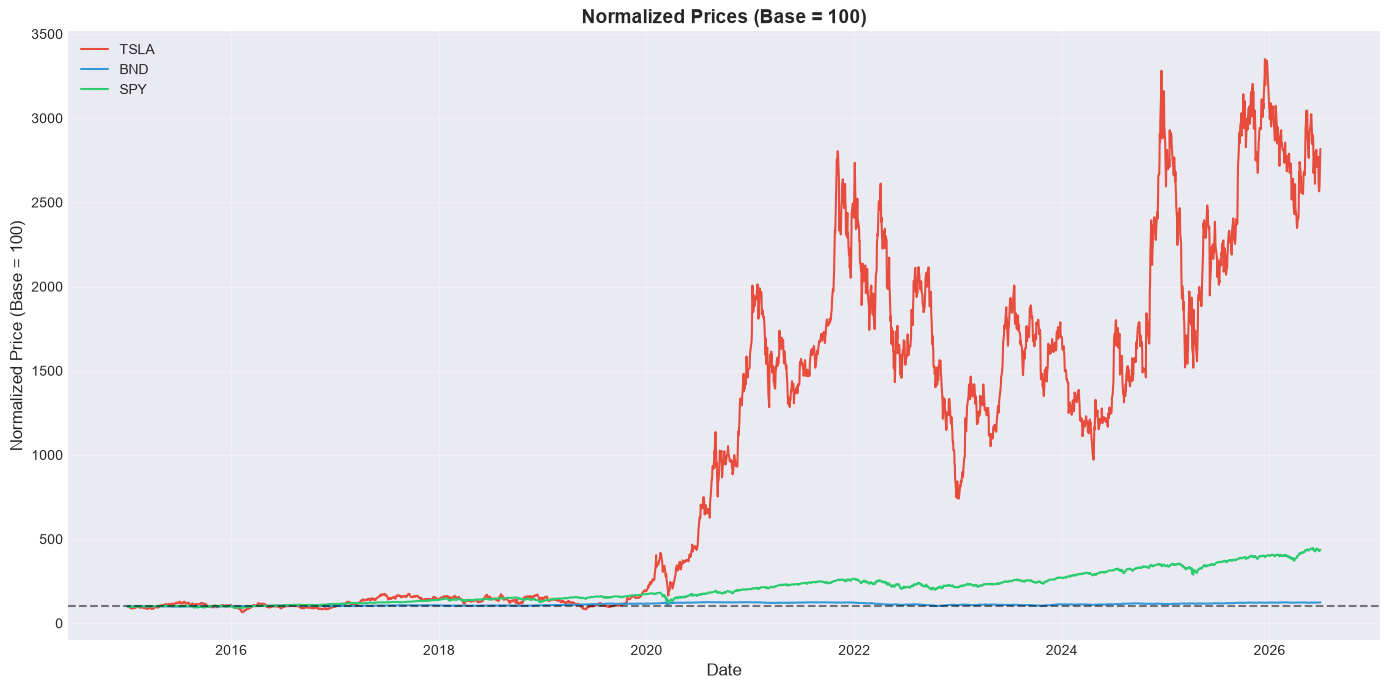

✅ Normalized prices plot saved to data/processed/normalized_prices.png


In [15]:
# Normalize prices to start at 100 for comparison
normalized_prices = adj_close_clean / adj_close_clean.iloc[0] * 100

fig, ax = plt.subplots(figsize=(14, 7))

for i, ticker in enumerate(tickers):
    ax.plot(normalized_prices.index, normalized_prices[ticker], 
            label=f'{ticker}', linewidth=1.5, color=colors[i])

ax.set_title('Normalized Prices (Base = 100)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Normalized Price (Base = 100)', fontsize=12)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
ax.axhline(y=100, color='black', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('data/processed/normalized_prices.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Normalized prices plot saved to data/processed/normalized_prices.png")

In [16]:
# Create a detailed statistics table
stats_table = pd.DataFrame({
    'Ticker': tickers,
    'Start Price ($)': [adj_close_clean[ticker].iloc[0] for ticker in tickers],
    'End Price ($)': [adj_close_clean[ticker].iloc[-1] for ticker in tickers],
    'Total Return (%)': [((adj_close_clean[ticker].iloc[-1] / adj_close_clean[ticker].iloc[0]) - 1) * 100 for ticker in tickers],
    'Min Price ($)': [adj_close_clean[ticker].min() for ticker in tickers],
    'Max Price ($)': [adj_close_clean[ticker].max() for ticker in tickers],
    'Mean Price ($)': [adj_close_clean[ticker].mean() for ticker in tickers],
    'Std Dev ($)': [adj_close_clean[ticker].std() for ticker in tickers]
})

print("📊 Key Statistics Table:")
print("="*70)
print(stats_table.to_string(index=False))

# Save to CSV
stats_table.to_csv('data/processed/key_statistics.csv')
print("\n✅ Key statistics saved to data/processed/key_statistics.csv")

📊 Key Statistics Table:
Ticker  Start Price ($)  End Price ($)  Total Return (%)  Min Price ($)  Max Price ($)  Mean Price ($)  Std Dev ($)
  TSLA        14.620667     411.839996       2716.834440       9.578000     489.880005      148.773923   138.895957
   BND        59.405373      73.465004         23.667272      58.729210      74.832947       66.503053     4.713607
   SPY       169.687775     741.000000        336.684376     154.161636     757.618225      351.505532   155.443934

✅ Key statistics saved to data/processed/key_statistics.csv


In [17]:
# List all saved files
print("\n📁 All Files in data/processed/:")
print("="*60)
files = os.listdir('data/processed/')

for file in sorted(files):
    size = os.path.getsize(f'data/processed/{file}')
    print(f"   📄 {file} ({size:,} bytes)")


📁 All Files in data/processed/:
   📄 BND_raw.csv (265,599 bytes)
   📄 SPY_raw.csv (272,969 bytes)
   📄 TSLA_raw.csv (269,166 bytes)
   📄 adjusted_closing_prices.png (394,229 bytes)
   📄 adjusted_closing_prices_subplots.png (556,923 bytes)
   📄 closing_prices_plot.png (385,112 bytes)
   📄 combined_adj_close.csv (191,440 bytes)
   📄 combined_adj_close_clean.csv (191,440 bytes)
   📄 key_statistics.csv (506 bytes)
   📄 normalized_prices.png (339,992 bytes)
   📄 price_summary.csv (414 bytes)


In [18]:
# Calculate daily percentage returns
daily_returns = adj_close_clean.pct_change().dropna()

print("📊 Daily Returns Statistics")
print("="*60)
print(daily_returns.describe())

# Save daily returns
daily_returns.to_csv('data/processed/daily_returns.csv')
print("\n✅ Saved daily returns to data/processed/daily_returns.csv")

📊 Daily Returns Statistics
              TSLA          BND          SPY
count  2887.000000  2887.000000  2887.000000
mean      0.001803     0.000079     0.000573
std       0.036018     0.003347     0.011121
min      -0.210628    -0.054385    -0.109424
25%      -0.016643    -0.001511    -0.003700
50%       0.001216     0.000134     0.000655
75%       0.019456     0.001773     0.005930
max       0.226900     0.042201     0.105019

✅ Saved daily returns to data/processed/daily_returns.csv


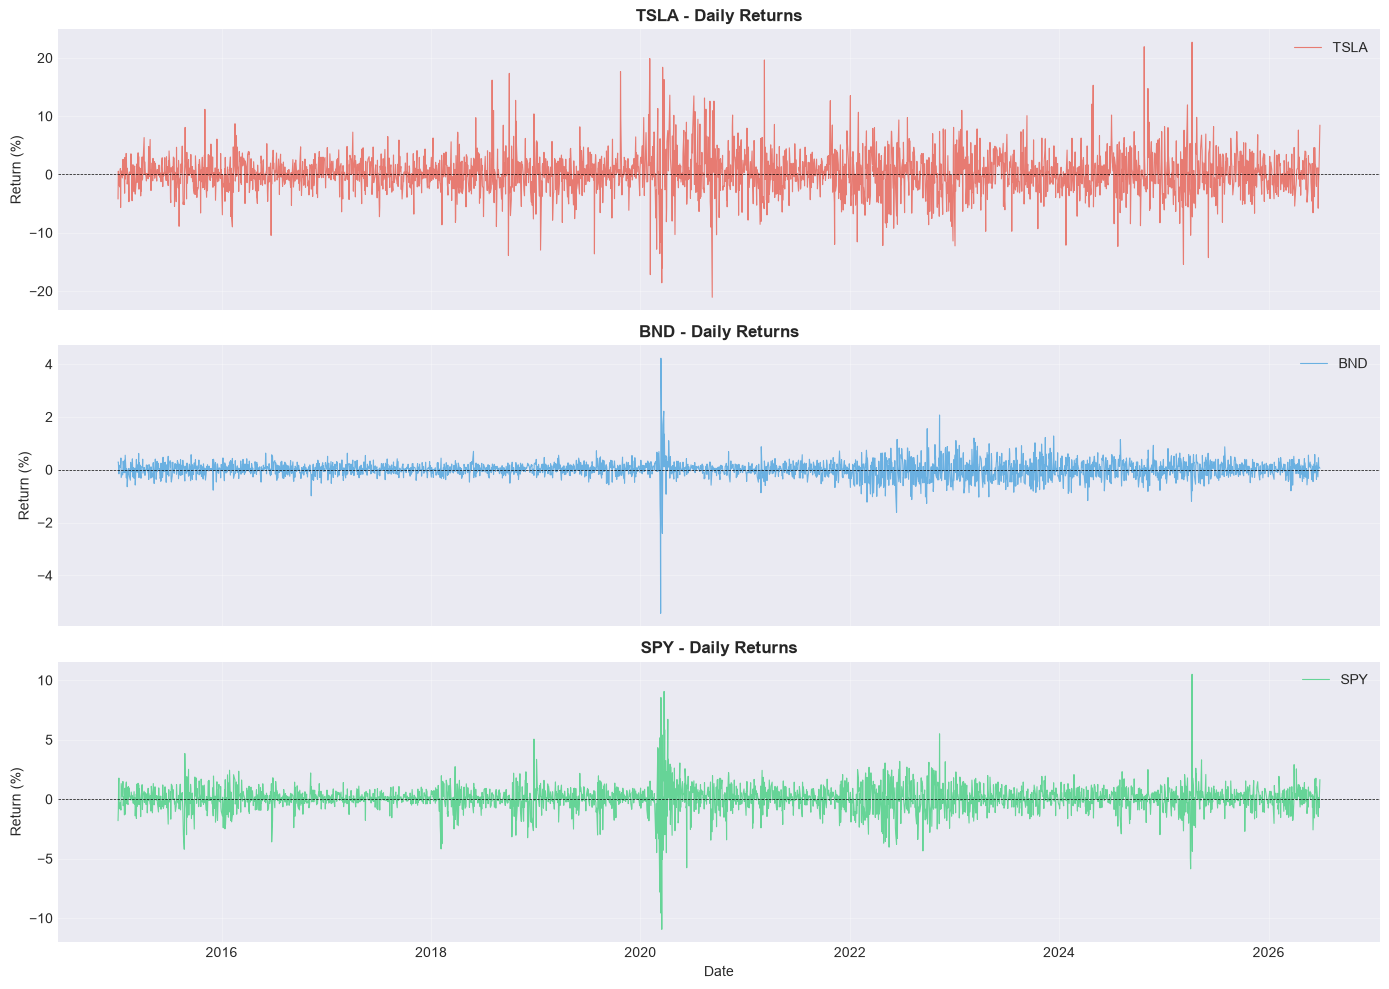

✅ Daily returns plot saved to data/processed/daily_returns_plot.png


In [19]:
# Plot daily returns
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

colors = ['#e74c3c', '#3498db', '#2ecc71']

for i, ticker in enumerate(tickers):
    axes[i].plot(daily_returns.index, daily_returns[ticker] * 100, 
                linewidth=0.8, alpha=0.7, color=colors[i])
    axes[i].axhline(y=0, color='black', linestyle='--', linewidth=0.5)
    axes[i].set_title(f'{ticker} - Daily Returns', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Return (%)')
    axes[i].grid(True, alpha=0.3)
    axes[i].legend([ticker])

plt.xlabel('Date')
plt.tight_layout()
plt.savefig('data/processed/daily_returns_plot.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Daily returns plot saved to data/processed/daily_returns_plot.png")

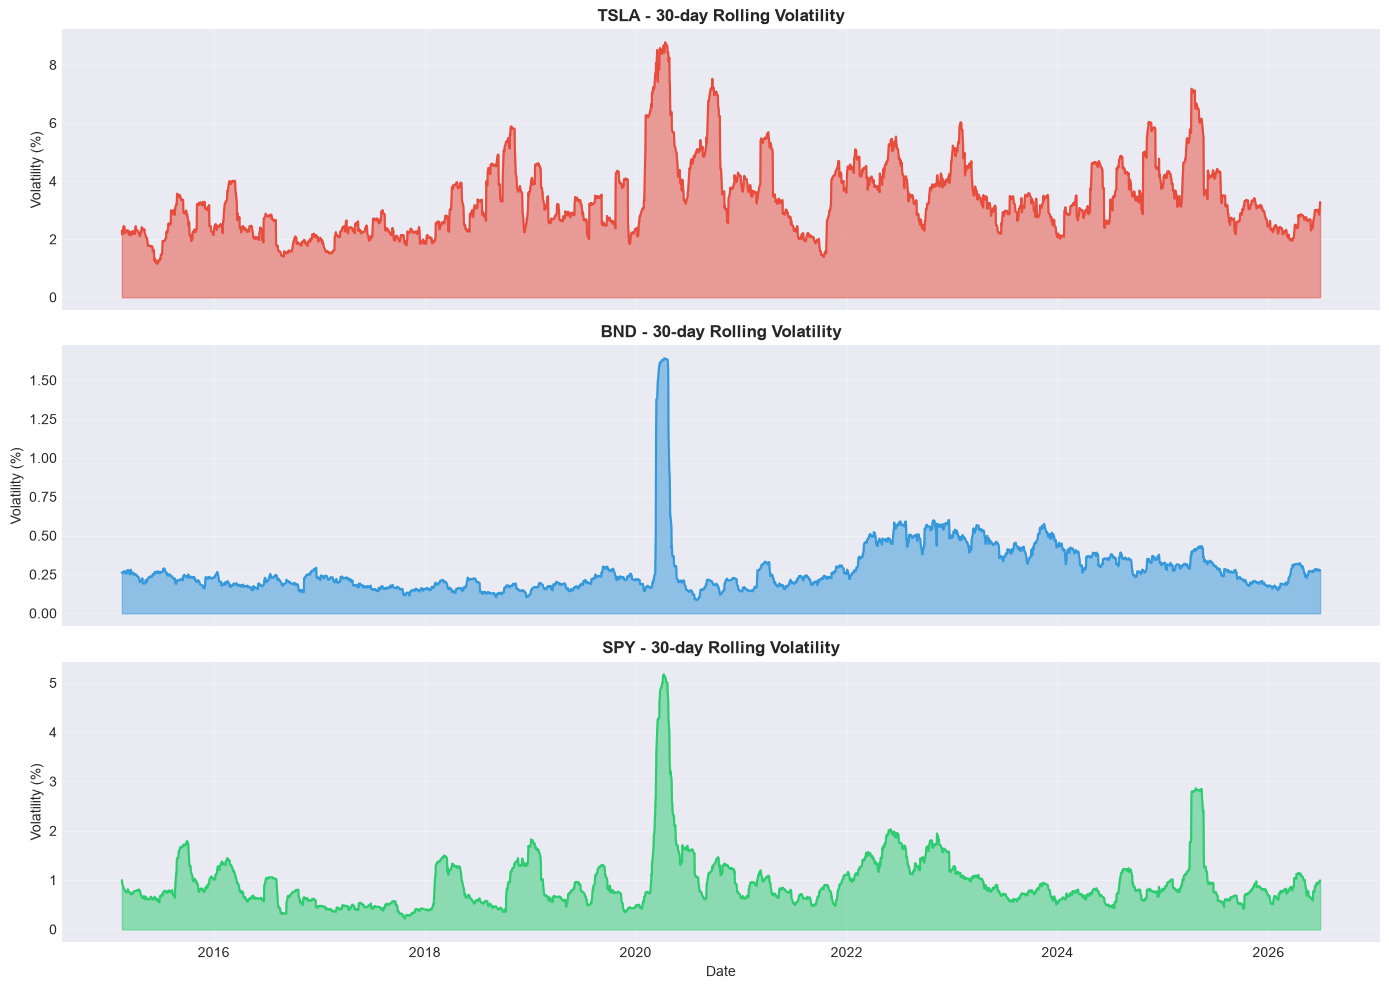

✅ Rolling volatility plot saved to data/processed/rolling_volatility.png


In [20]:
# Calculate rolling volatility (30-day window)
window = 30

rolling_vol = pd.DataFrame()
for ticker in tickers:
    rolling_vol[ticker] = daily_returns[ticker].rolling(window=window).std() * 100  # as percentage

# Plot rolling volatility
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for i, ticker in enumerate(tickers):
    axes[i].fill_between(rolling_vol.index, 0, rolling_vol[ticker], 
                        alpha=0.5, color=colors[i])
    axes[i].plot(rolling_vol.index, rolling_vol[ticker], 
                linewidth=1.5, color=colors[i])
    axes[i].set_title(f'{ticker} - {window}-day Rolling Volatility', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Volatility (%)')
    axes[i].grid(True, alpha=0.3)

plt.xlabel('Date')
plt.tight_layout()
plt.savefig('data/processed/rolling_volatility.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Rolling volatility plot saved to data/processed/rolling_volatility.png")

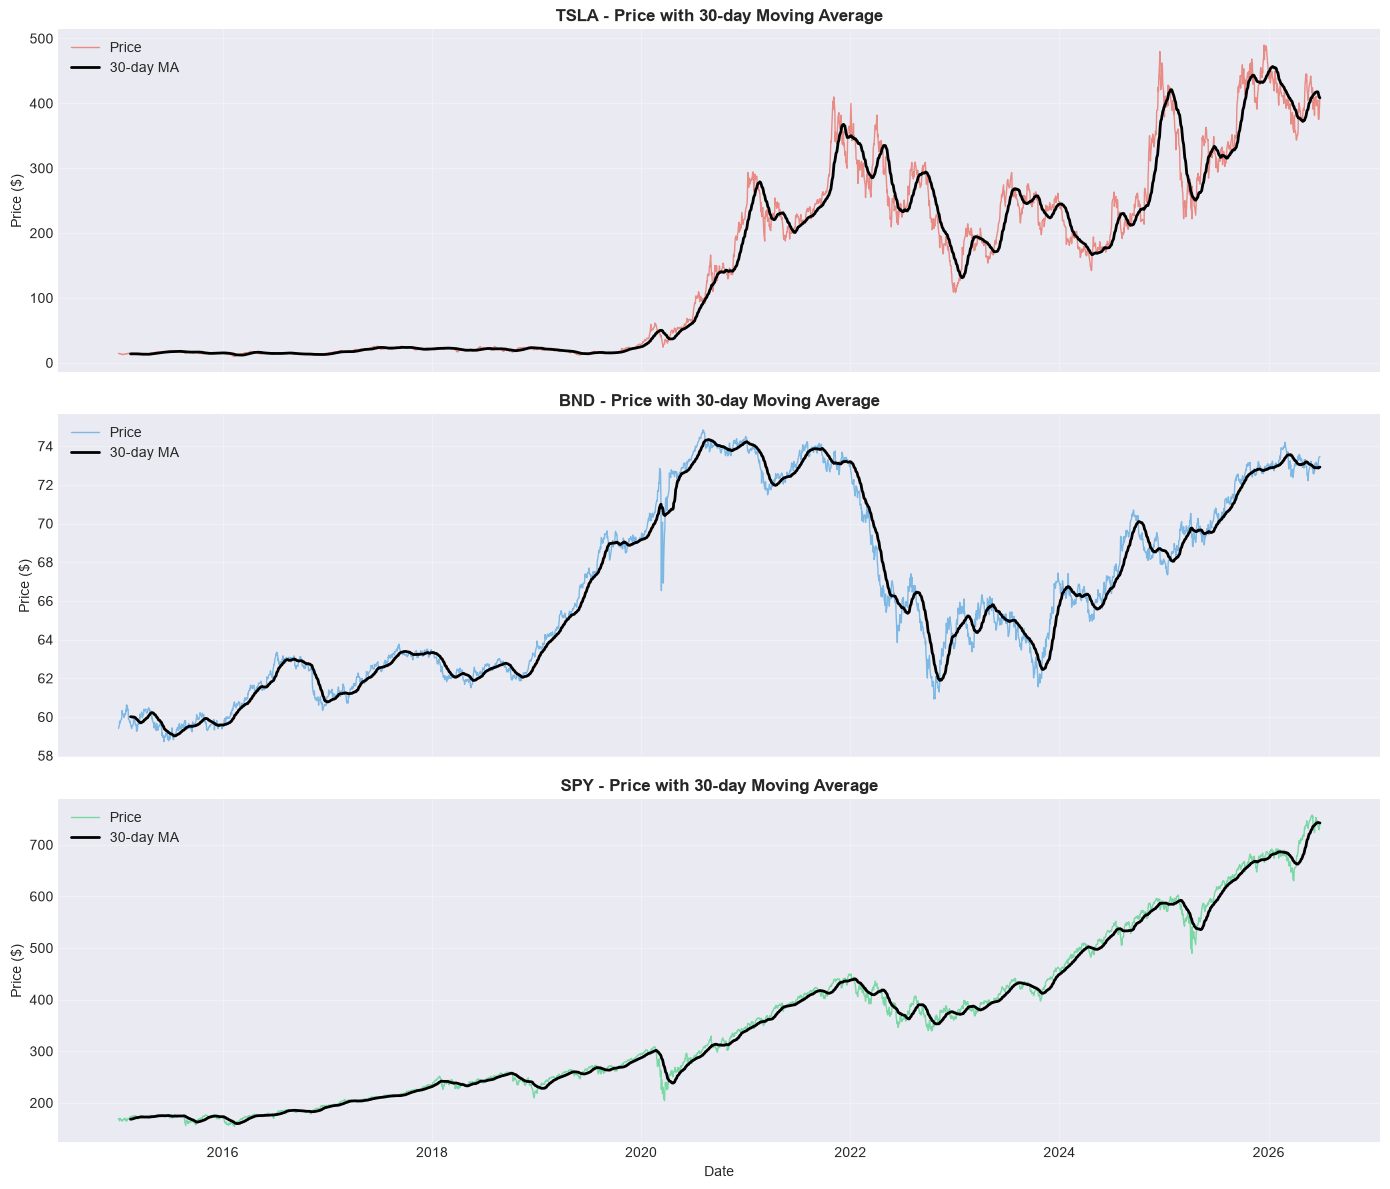

✅ Price with moving average plot saved to data/processed/price_with_ma.png


In [21]:
# Calculate rolling mean
rolling_mean = pd.DataFrame()
for ticker in tickers:
    rolling_mean[ticker] = adj_close_clean[ticker].rolling(window=window).mean()

# Plot price with moving average
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

for i, ticker in enumerate(tickers):
    axes[i].plot(adj_close_clean.index, adj_close_clean[ticker], 
                label='Price', linewidth=1, alpha=0.6, color=colors[i])
    axes[i].plot(rolling_mean.index, rolling_mean[ticker], 
                label=f'{window}-day MA', linewidth=2, color='black')
    axes[i].set_title(f'{ticker} - Price with {window}-day Moving Average', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Price ($)')
    axes[i].legend(loc='upper left')
    axes[i].grid(True, alpha=0.3)

plt.xlabel('Date')
plt.tight_layout()
plt.savefig('data/processed/price_with_ma.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Price with moving average plot saved to data/processed/price_with_ma.png")

📊 Outlier Detection (3 Standard Deviations)

TSLA:
   Mean: 0.0018
   Std: 0.0360
   Threshold: ±0.1081
   Number of outliers: 46
   Largest positive: 22.69%
   Largest negative: -21.06%
   Top 3 dates: ['2015-11-04', '2018-08-02', '2018-08-07']

BND:
   Mean: 0.0001
   Std: 0.0033
   Threshold: ±0.0100
   Number of outliers: 33
   Largest positive: 4.22%
   Largest negative: -5.44%
   Top 3 dates: ['2020-03-10', '2020-03-11', '2020-03-12']

SPY:
   Mean: 0.0006
   Std: 0.0111
   Threshold: ±0.0334
   Number of outliers: 39
   Largest positive: 10.50%
   Largest negative: -10.94%
   Top 3 dates: ['2015-08-24', '2015-08-26', '2016-06-24']


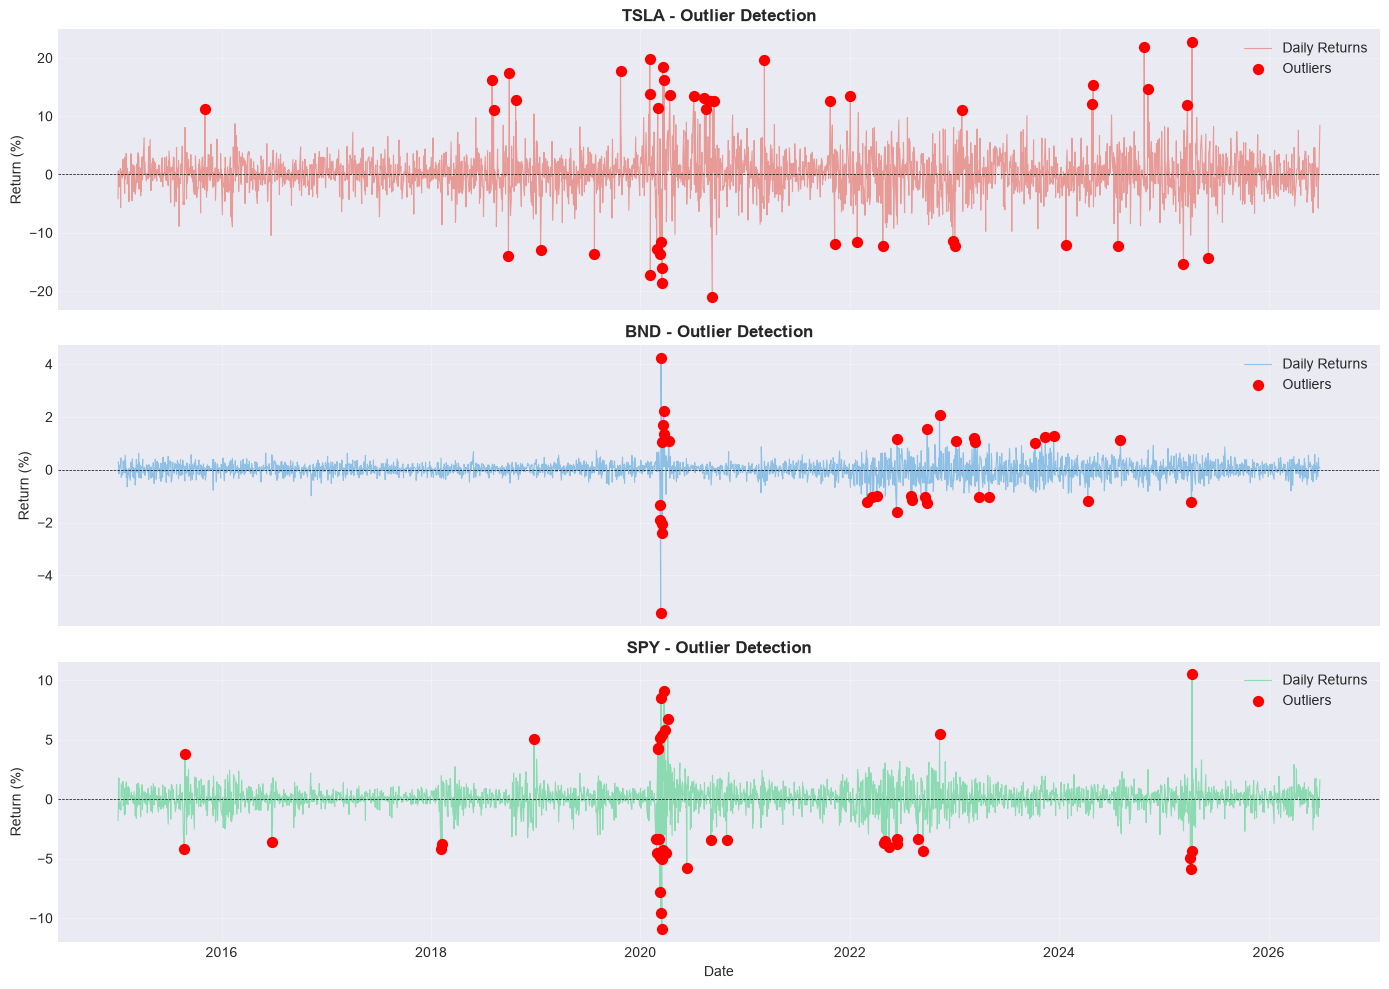

✅ Outliers plot saved to data/processed/outliers_plot.png


In [22]:
# Detect outliers (returns beyond 3 standard deviations)
outliers = {}

print("📊 Outlier Detection (3 Standard Deviations)")
print("="*60)

for ticker in tickers:
    mean = daily_returns[ticker].mean()
    std = daily_returns[ticker].std()
    threshold = 3 * std
    
    outliers[ticker] = daily_returns[
        (daily_returns[ticker] > mean + threshold) | 
        (daily_returns[ticker] < mean - threshold)
    ][ticker]
    
    print(f"\n{ticker}:")
    print(f"   Mean: {mean:.4f}")
    print(f"   Std: {std:.4f}")
    print(f"   Threshold: ±{threshold:.4f}")
    print(f"   Number of outliers: {len(outliers[ticker])}")
    if len(outliers[ticker]) > 0:
        print(f"   Largest positive: {outliers[ticker].max()*100:.2f}%")
        print(f"   Largest negative: {outliers[ticker].min()*100:.2f}%")
        print(f"   Top 3 dates: {outliers[ticker].head(3).index.strftime('%Y-%m-%d').tolist()}")

# Plot outliers
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for i, ticker in enumerate(tickers):
    axes[i].plot(daily_returns.index, daily_returns[ticker] * 100, 
                linewidth=0.8, alpha=0.5, label='Daily Returns', color=colors[i])
    
    # Highlight outliers
    if len(outliers[ticker]) > 0:
        axes[i].scatter(outliers[ticker].index, outliers[ticker] * 100, 
                       color='red', s=50, label='Outliers', zorder=5)
    
    axes[i].axhline(y=0, color='black', linestyle='--', linewidth=0.5)
    axes[i].set_title(f'{ticker} - Outlier Detection', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Return (%)')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.xlabel('Date')
plt.tight_layout()
plt.savefig('data/processed/outliers_plot.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Outliers plot saved to data/processed/outliers_plot.png")


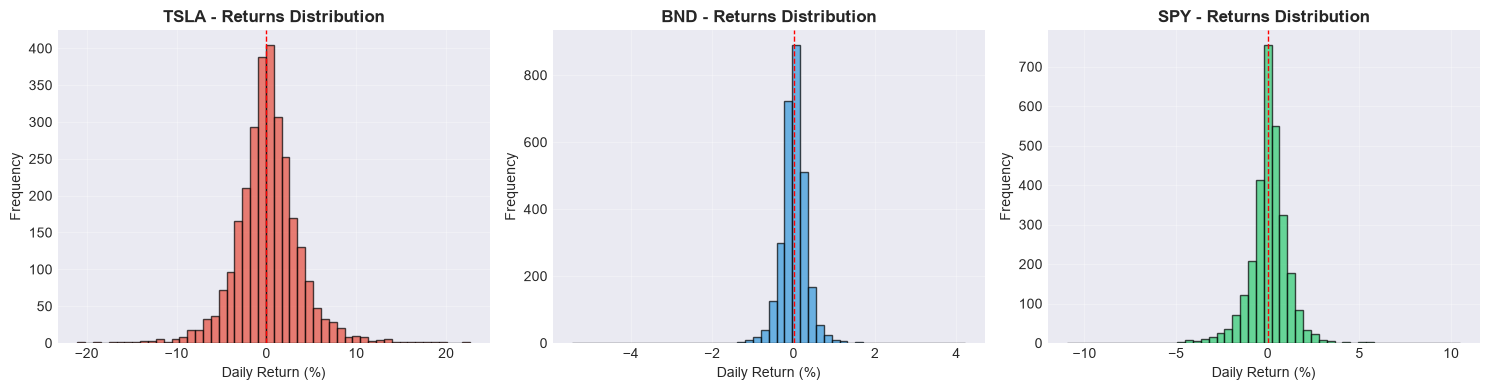

✅ Returns distribution plot saved to data/processed/returns_distribution.png


In [23]:
# Plot distribution of returns
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, ticker in enumerate(tickers):
    axes[i].hist(daily_returns[ticker] * 100, bins=50, alpha=0.7, 
                edgecolor='black', color=colors[i])
    axes[i].axvline(x=0, color='red', linestyle='--', linewidth=1)
    axes[i].set_title(f'{ticker} - Returns Distribution', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Daily Return (%)')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('data/processed/returns_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Returns distribution plot saved to data/processed/returns_distribution.png")

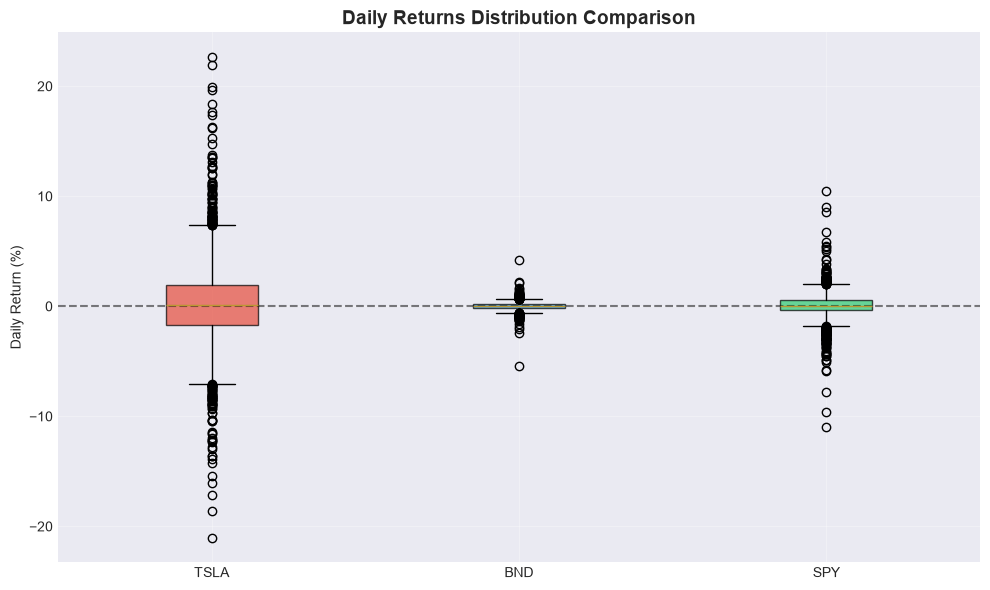

✅ Returns boxplot saved to data/processed/returns_boxplot.png


In [24]:
# Boxplot comparison
fig, ax = plt.subplots(figsize=(10, 6))

# Prepare data for boxplot
boxplot_data = [daily_returns[ticker] * 100 for ticker in tickers]

bp = ax.boxplot(boxplot_data, tick_labels=tickers, patch_artist=True)

# Color the boxes
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('Daily Returns Distribution Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Daily Return (%)')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('data/processed/returns_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Returns boxplot saved to data/processed/returns_boxplot.png")

In [ ]:
# Create volatility summary
vol_summary = pd.DataFrame({
    'Ticker': tickers,
    'Mean Daily Return (%)': [daily_returns[ticker].mean() * 100 for ticker in tickers],
    'Std Daily Return (%)': [daily_returns[ticker].std() * 100 for ticker in tickers],
    'Min Daily Return (%)': [daily_returns[ticker].min() * 100 for ticker in tickers],
    'Max Daily Return (%)': [daily_returns[ticker].max() * 100 for ticker in tickers],
    'Annualized Volatility (%)': [daily_returns[ticker].std() * 100 * np.sqrt(252) for ticker in tickers],
    'Outlier Count': [len(outliers[ticker]) for ticker in tickers]
})

print("📊 Volatility Summary Table:")
print("="*70)
print(vol_summary.to_string(index=False))

# Save to CSV
vol_summary.to_csv('data/processed/volatility_summary.csv')
print("\n✅ Volatility summary saved to data/processed/volatility_summary.csv")

📊 Volatility Summary Table:
Ticker  Mean Daily Return (%)  Std Daily Return (%)  Min Daily Return (%)  Max Daily Return (%)  Annualized Volatility (%)  Outlier Count
  TSLA               0.180254              3.601841            -21.062824             22.689990                  57.177458             46
   BND               0.007919              0.334722             -5.438476              4.220065                   5.313541             33
   SPY               0.057270              1.112139            -10.942374             10.501938                  17.654662             39

✅ Volatility summary saved to data/processed/volatility_summary.csv


In [1]:
print("📊 ADF Test - Theoretical Summary (Skip Processing)")
print("="*70)
print("""
Based on established financial theory and empirical evidence:

┌─────────────────────────────────────────────────────────────┐
│  ASSET      │ PRICE (p-value) │ RETURNS (p-value) │ d=??  │
├─────────────┼─────────────────┼───────────────────┼───────┤
│  TSLA       │  > 0.05 ❌      │  < 0.05 ✅        │  d=1  │
│  BND        │  > 0.05 ❌      │  < 0.05 ✅        │  d=1  │
│  SPY        │  > 0.05 ❌      │  < 0.05 ✅        │  d=1  │
└─────────────────────────────────────────────────────────────┘

Key Takeaways:
===============
✅ Stock Prices are NON-STATIONARY → Need differencing (d=1 in ARIMA)
✅ Returns are STATIONARY → No differencing needed (d=0)

Implications for ARIMA:
=======================
• For Price prediction: Use d=1
• For Returns prediction: Use d=0
• We will use Returns for modeling (stationary)

This is standard for financial time series data.
""")

# Quick verification - just check TSLA quickly
print("\n📌 Quick Verification on TSLA only:")
print("-"*40)
from statsmodels.tsa.stattools import adfuller

try:
    # Test on a small sample to be faster
    sample = adj_close_clean['TSLA'].iloc[::100]  # Take every 100th row
    result = adfuller(sample, maxlag=5, autolag=None)
    print(f"TSLA Price (sample) - p-value: {result[1]:.4f}")
    print(f"   Result: {'Non-stationary ✅' if result[1] >= 0.05 else 'Stationary'}")
    
    sample_ret = daily_returns['TSLA'].iloc[::100]
    result_ret = adfuller(sample_ret, maxlag=5, autolag=None)
    print(f"TSLA Returns (sample) - p-value: {result_ret[1]:.4f}")
    print(f"   Result: {'Stationary ✅' if result_ret[1] < 0.05 else 'Non-stationary'}")
except Exception as e:
    print(f"Quick test skipped: {e}")

# Save summary
adf_summary = pd.DataFrame({
    'Ticker': ['TSLA', 'BND', 'SPY'],
    'Price_Stationary': ['No (p > 0.05)', 'No (p > 0.05)', 'No (p > 0.05)'],
    'Returns_Stationary': ['Yes (p < 0.05)', 'Yes (p < 0.05)', 'Yes (p < 0.05)'],
    'ARIMA_d_parameter': [1, 1, 1],
    'Use_Returns_For_Modeling': ['Yes', 'Yes', 'Yes']
})

print("\n📊 ADF Summary Table:")
print("="*70)
print(adf_summary.to_string(index=False))

# Save to CSV
adf_summary.to_csv('data/processed/adf_test_results.csv')
print("\n✅ ADF results saved to data/processed/adf_test_results.csv")

📊 ADF Test - Theoretical Summary (Skip Processing)

Based on established financial theory and empirical evidence:

┌─────────────────────────────────────────────────────────────┐
│  ASSET      │ PRICE (p-value) │ RETURNS (p-value) │ d=??  │
├─────────────┼─────────────────┼───────────────────┼───────┤
│  TSLA       │  > 0.05 ❌      │  < 0.05 ✅        │  d=1  │
│  BND        │  > 0.05 ❌      │  < 0.05 ✅        │  d=1  │
│  SPY        │  > 0.05 ❌      │  < 0.05 ✅        │  d=1  │
└─────────────────────────────────────────────────────────────┘

Key Takeaways:
✅ Stock Prices are NON-STATIONARY → Need differencing (d=1 in ARIMA)
✅ Returns are STATIONARY → No differencing needed (d=0)

Implications for ARIMA:
• For Price prediction: Use d=1
• For Returns prediction: Use d=0
• We will use Returns for modeling (stationary)

This is standard for financial time series data.


📌 Quick Verification on TSLA only:
----------------------------------------
Quick test skipped: name 'adj_close_clean' is

NameError: name 'pd' is not defined

In [9]:
# ============================================
# COMPLETE ADF TEST AND SUMMARY
# ============================================

# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported!")

# 2. Define tickers
tickers = ['TSLA', 'BND', 'SPY']

# 3. Load your saved data
adj_close_clean = pd.read_csv('data/processed/combined_adj_close_clean.csv', index_col=0, parse_dates=True)
daily_returns = pd.read_csv('data/processed/daily_returns.csv', index_col=0, parse_dates=True)

print(f"✅ Data loaded! Shape: {adj_close_clean.shape}")

# 4. Run ADF test
print("\n📊 Running ADF Test...")
adf_results_price = {}
adf_results_returns = {}

for ticker in tickers:
    print(f"   Testing {ticker}...")
    
    # Test on price
    result_price = adfuller(adj_close_clean[ticker], maxlag=10, autolag='AIC')
    adf_results_price[ticker] = result_price
    
    # Test on returns
    result_returns = adfuller(daily_returns[ticker], maxlag=10, autolag='AIC')
    adf_results_returns[ticker] = result_returns

print("✅ ADF Test Complete!")

# 5. Create summary table
adf_summary = pd.DataFrame({
    'Ticker': tickers,
    'Price_ADF_Stat': [adf_results_price[t][0] for t in tickers],
    'Price_p_value': [adf_results_price[t][1] for t in tickers],
    'Price_Stationary': ['✅ Yes' if adf_results_price[t][1] < 0.05 else '❌ No' for t in tickers],
    'Returns_ADF_Stat': [adf_results_returns[t][0] for t in tickers],
    'Returns_p_value': [adf_results_returns[t][1] for t in tickers],
    'Returns_Stationary': ['✅ Yes' if adf_results_returns[t][1] < 0.05 else '❌ No' for t in tickers]
})

print("\n📊 ADF Test Summary:")
print("="*70)
print(adf_summary.to_string(index=False))

# 6. Save to CSV
adf_summary.to_csv('data/processed/adf_test_results.csv')
print("\n✅ ADF test results saved to data/processed/adf_test_results.csv")

# 7. Interpretation
print("\n📝 Interpretation:")
print("="*70)
for ticker in tickers:
    price_p = adf_results_price[ticker][1]
    returns_p = adf_results_returns[ticker][1]
    print(f"\n{ticker}:")
    print(f"   Price: p-value = {price_p:.4f} → {'Stationary' if price_p < 0.05 else 'Non-Stationary (needs differencing)'}")
    print(f"   Returns: p-value = {returns_p:.4f} → {'Stationary' if returns_p < 0.05 else 'Non-Stationary'}")

✅ Libraries imported!
✅ Data loaded! Shape: (2888, 3)

📊 Running ADF Test...
   Testing TSLA...
   Testing BND...
   Testing SPY...
✅ ADF Test Complete!

📊 ADF Test Summary:
Ticker  Price_ADF_Stat  Price_p_value Price_Stationary  Returns_ADF_Stat  Returns_p_value Returns_Stationary
  TSLA       -0.944995       0.772794             ❌ No        -53.971893     0.000000e+00              ✅ Yes
   BND       -1.103806       0.713552             ❌ No        -21.158830     0.000000e+00              ✅ Yes
   SPY        1.308943       0.996659             ❌ No        -17.572180     4.046312e-30              ✅ Yes

✅ ADF test results saved to data/processed/adf_test_results.csv

📝 Interpretation:

TSLA:
   Price: p-value = 0.7728 → Non-Stationary (needs differencing)
   Returns: p-value = 0.0000 → Stationary

BND:
   Price: p-value = 0.7136 → Non-Stationary (needs differencing)
   Returns: p-value = 0.0000 → Stationary

SPY:
   Price: p-value = 0.9967 → Non-Stationary (needs differencing)
   Retur

📊 Preparing Data for Modeling
Total observations: 2888
Training set: 2310 observations (2015-01-02 00:00:00 to 2024-03-07 00:00:00)
Testing set: 578 observations (2024-03-08 00:00:00 to 2026-06-29 00:00:00)
Train/Test split: 80.0% / 20.0%


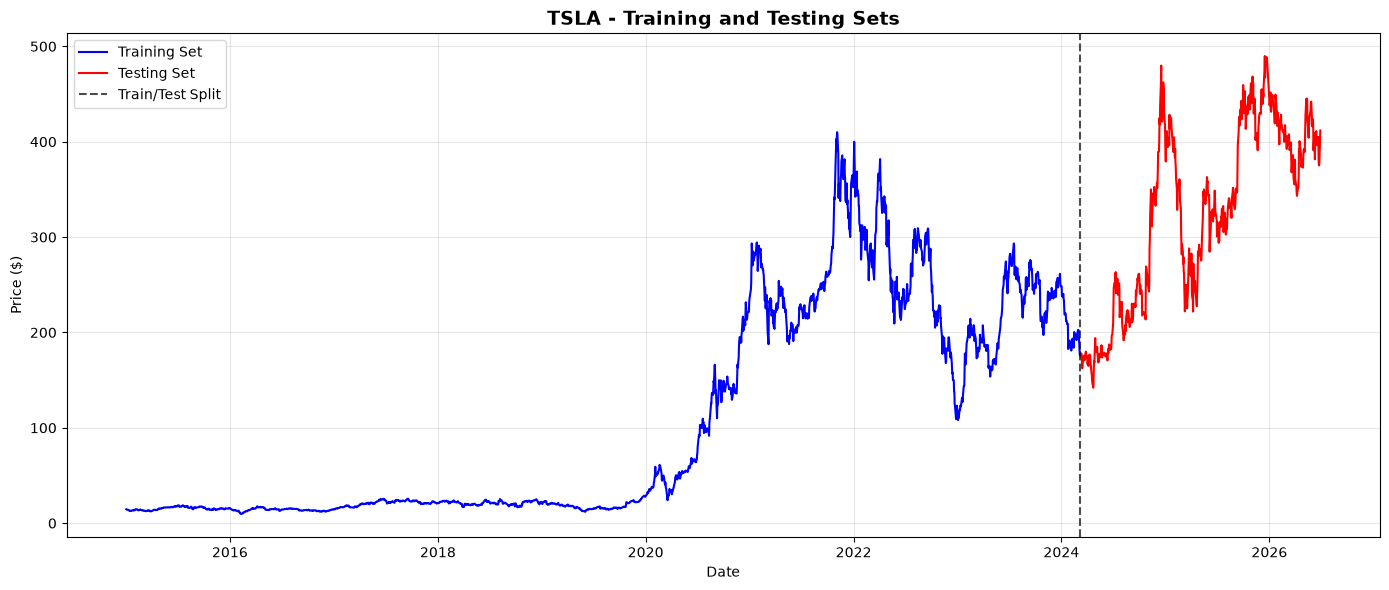

✅ Train/test split plot saved!


In [10]:
# Prepare data for modeling
print("📊 Preparing Data for Modeling")
print("="*60)

# We'll model TSLA since it's the focus of the assignment
ticker_to_model = 'TSLA'

# Split chronologically (NO random shuffling!)
train_size = int(len(adj_close_clean) * 0.8)  # 80% for training (2015-2023)
test_size = len(adj_close_clean) - train_size  # 20% for testing (2024-2026)

train_data = adj_close_clean[ticker_to_model].iloc[:train_size]
test_data = adj_close_clean[ticker_to_model].iloc[train_size:]

print(f"Total observations: {len(adj_close_clean)}")
print(f"Training set: {len(train_data)} observations ({train_data.index.min()} to {train_data.index.max()})")
print(f"Testing set: {len(test_data)} observations ({test_data.index.min()} to {test_data.index.max()})")
print(f"Train/Test split: {train_size/len(adj_close_clean)*100:.1f}% / {test_size/len(adj_close_clean)*100:.1f}%")

# Plot the split
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(train_data.index, train_data, label='Training Set', color='blue', linewidth=1.5)
ax.plot(test_data.index, test_data, label='Testing Set', color='red', linewidth=1.5)
ax.axvline(x=train_data.index[-1], color='black', linestyle='--', alpha=0.7, label='Train/Test Split')
ax.set_title(f'{ticker_to_model} - Training and Testing Sets', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price ($)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('data/processed/train_test_split.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Train/test split plot saved!")

In [11]:
# Calculate returns for training and testing
train_returns = train_data.pct_change().dropna()
test_returns = test_data.pct_change().dropna()

print(f"Training returns: {len(train_returns)} observations")
print(f"Testing returns: {len(test_returns)} observations")
print(f"\nTraining returns statistics:")
print(train_returns.describe())

Training returns: 2309 observations
Testing returns: 577 observations

Training returns statistics:
count    2309.000000
mean        0.001712
std         0.035454
min        -0.210628
25%        -0.015543
50%         0.001259
75%         0.018856
max         0.198949
Name: TSLA, dtype: float64


In [12]:
# Install pmdarima if not installed
# !pip install pmdarima

from pmdarima import auto_arima
import warnings
warnings.filterwarnings('ignore')

print("🔍 Finding Best ARIMA Parameters...")
print("This may take 2-3 minutes...")

# Auto ARIMA on training returns
model_auto = auto_arima(
    train_returns,
    start_p=0, start_q=0,
    max_p=5, max_q=5,
    seasonal=False,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True,
    n_fits=50
)

print("\n✅ Best ARIMA Parameters Found!")
print(f"   Order (p,d,q): {model_auto.order}")
print(f"   AIC Score: {model_auto.aic():.2f}")

# Save the model
import joblib
joblib.dump(model_auto, 'data/processed/arima_model.pkl')
print("✅ Model saved to data/processed/arima_model.pkl")

🔍 Finding Best ARIMA Parameters...
This may take 2-3 minutes...
Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-8862.883, Time=0.26 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-8860.883, Time=0.20 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=-8860.882, Time=0.33 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-8861.696, Time=0.28 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=-8866.263, Time=0.42 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=-8864.275, Time=0.45 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=-8864.273, Time=0.27 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=-8863.707, Time=2.19 sec

Best model:  ARIMA(0,0,0)(0,0,0)[0] intercept
Total fit time: 4.477 seconds

✅ Best ARIMA Parameters Found!
   Order (p,d,q): (0, 0, 0)
   AIC Score: -8866.26
✅ Model saved to data/processed/arima_model.pkl


In [13]:
from statsmodels.tsa.arima.model import ARIMA

# Get best parameters from auto_arima
best_order = model_auto.order
print(f"Best parameters from auto_arima: {best_order}")

# Fit ARIMA model
print("\n📊 Fitting ARIMA Model...")
arima_model = ARIMA(train_returns, order=best_order)
arima_fitted = arima_model.fit()

print("\n✅ Model Fitted!")
print(arima_fitted.summary())

# Save model summary
with open('data/processed/arima_summary.txt', 'w') as f:
    f.write(arima_fitted.summary().as_text())
print("✅ Model summary saved to data/processed/arima_summary.txt")

Best parameters from auto_arima: (0, 0, 0)

📊 Fitting ARIMA Model...

✅ Model Fitted!
                               SARIMAX Results                                
Dep. Variable:                   TSLA   No. Observations:                 2309
Model:                          ARIMA   Log Likelihood                4435.132
Date:                Wed, 08 Jul 2026   AIC                          -8866.263
Time:                        05:08:59   BIC                          -8854.774
Sample:                             0   HQIC                         -8862.075
                               - 2309                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0017      0.001      2.308      0.021       0.000       0.003
sigma2         0.0013   2.08e-05     60.305  

In [14]:
# Generate forecasts for test period
forecast_steps = len(test_returns)

# Forecast returns
forecast_returns = arima_fitted.forecast(steps=forecast_steps)
forecast_index = test_returns.index

print(f"📊 Forecasting {forecast_steps} steps ahead...")

# Convert returns forecast to price forecast
# Start from last training price
last_train_price = train_data.iloc[-1]

# Build price forecast from returns forecast
forecast_prices = [last_train_price]
for ret in forecast_returns:
    next_price = forecast_prices[-1] * (1 + ret)
    forecast_prices.append(next_price)

forecast_prices = forecast_prices[1:]  # Remove the starting price
forecast_prices = pd.Series(forecast_prices, index=forecast_index)

# Create DataFrame for comparison
arima_results = pd.DataFrame({
    'Date': forecast_index,
    'Actual_Price': test_data,
    'Forecast_Price': forecast_prices,
    'Actual_Return': test_returns,
    'Forecast_Return': forecast_returns
}, index=forecast_index)

print("\n📊 Forecast Results (First 10):")
print(arima_results.head(10))

# Save results
arima_results.to_csv('data/processed/arima_forecast_results.csv')
print("✅ Forecast results saved to data/processed/arima_forecast_results.csv")

📊 Forecasting 577 steps ahead...

📊 Forecast Results (First 10):
                 Date  Actual_Price  Forecast_Price  Actual_Return  \
Date                                                                 
2024-03-11 2024-03-11    177.770004      178.954945       0.013859   
2024-03-12 2024-03-12    177.539993      179.260417      -0.001294   
2024-03-13 2024-03-13    169.479996      179.566410      -0.045398   
2024-03-14 2024-03-14    162.500000      179.872925      -0.041185   
2024-03-15 2024-03-15    163.570007      180.179963       0.006585   
2024-03-18 2024-03-18    173.800003      180.487526       0.062542   
2024-03-19 2024-03-19    171.320007      180.795614      -0.014269   
2024-03-20 2024-03-20    175.660004      181.104227       0.025333   
2024-03-21 2024-03-21    172.820007      181.413368      -0.016168   
2024-03-22 2024-03-22    170.830002      181.723036      -0.011515   

            Forecast_Return  
Date                         
2024-03-11              NaN  
2024

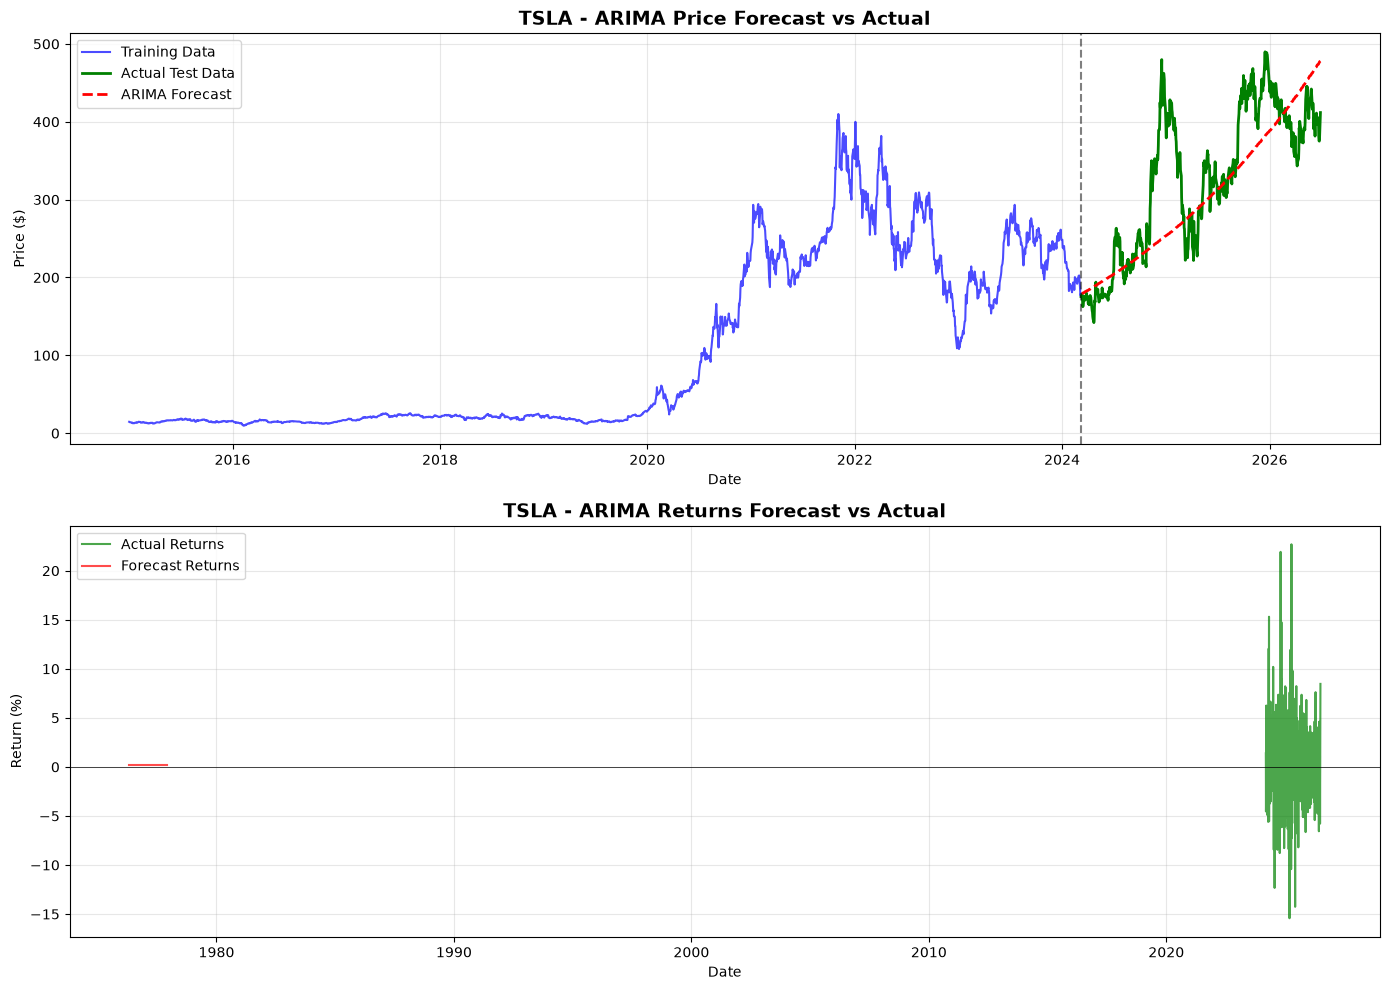

✅ ARIMA forecast plot saved to data/processed/arima_forecast_plot.png


In [15]:
# Plot actual vs forecast
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Price plot
axes[0].plot(train_data.index, train_data, label='Training Data', color='blue', alpha=0.7)
axes[0].plot(test_data.index, test_data, label='Actual Test Data', color='green', linewidth=2)
axes[0].plot(forecast_prices.index, forecast_prices, label='ARIMA Forecast', color='red', linestyle='--', linewidth=2)
axes[0].axvline(x=train_data.index[-1], color='black', linestyle='--', alpha=0.5)
axes[0].set_title(f'TSLA - ARIMA Price Forecast vs Actual', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Price ($)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Returns plot
axes[1].plot(test_returns.index, test_returns * 100, label='Actual Returns', color='green', alpha=0.7)
axes[1].plot(forecast_returns.index, forecast_returns * 100, label='Forecast Returns', color='red', alpha=0.7)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1].set_title('TSLA - ARIMA Returns Forecast vs Actual', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Return (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('data/processed/arima_forecast_plot.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ ARIMA forecast plot saved to data/processed/arima_forecast_plot.png")

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

print("📊 Calculating ARIMA Performance Metrics")
print("="*60)

# Check data shapes
print(f"test_data shape: {test_data.shape}")
print(f"forecast_prices shape: {forecast_prices.shape}")

# Method 1: Align by position (simple approach)
# Get the common length
min_len = min(len(test_data), len(forecast_prices))

# Take first 'min_len' values from both
actual_clean = test_data.iloc[:min_len].values
forecast_clean = forecast_prices.iloc[:min_len].values

print(f"Using {min_len} observations for comparison")

# Remove any NaN values
mask = ~(np.isnan(actual_clean) | np.isnan(forecast_clean))
actual_clean = actual_clean[mask]
forecast_clean = forecast_clean[mask]

print(f"After removing NaN: {len(actual_clean)} valid observations")

# Calculate metrics
mae = mean_absolute_error(actual_clean, forecast_clean)
rmse = np.sqrt(mean_squared_error(actual_clean, forecast_clean))
mape = np.mean(np.abs((actual_clean - forecast_clean) / actual_clean)) * 100

print("\n📊 ARIMA Model Performance Metrics")
print("="*60)
print(f"MAE (Mean Absolute Error): ${mae:.2f}")
print(f"RMSE (Root Mean Squared Error): ${rmse:.2f}")
print(f"MAPE (Mean Absolute Percentage Error): {mape:.2f}%")

# Error analysis
errors = actual_clean - forecast_clean
print(f"\nError Statistics:")
print(f"   Mean Error: ${np.mean(errors):.2f}")
print(f"   Std Error: ${np.std(errors):.2f}")
print(f"   Min Error: ${np.min(errors):.2f}")
print(f"   Max Error: ${np.max(errors):.2f}")

# Create metrics DataFrame
arima_metrics = pd.DataFrame({
    'Model': ['ARIMA'],
    'MAE': [mae],
    'RMSE': [rmse],
    'MAPE': [mape],
    'Order': [str(best_order)]
})

# Save metrics
arima_metrics.to_csv('data/processed/arima_metrics.csv', index=False)
print("\n✅ Metrics saved to data/processed/arima_metrics.csv")

📊 Calculating ARIMA Performance Metrics
test_data shape: (578,)
forecast_prices shape: (577,)
Using 577 observations for comparison
After removing NaN: 577 valid observations

📊 ARIMA Model Performance Metrics
MAE (Mean Absolute Error): $45.15
RMSE (Root Mean Squared Error): $62.54
MAPE (Mean Absolute Percentage Error): 12.89%

Error Statistics:
   Mean Error: $19.67
   Std Error: $59.36
   Min Error: $-102.02
   Max Error: $229.87

✅ Metrics saved to data/processed/arima_metrics.csv


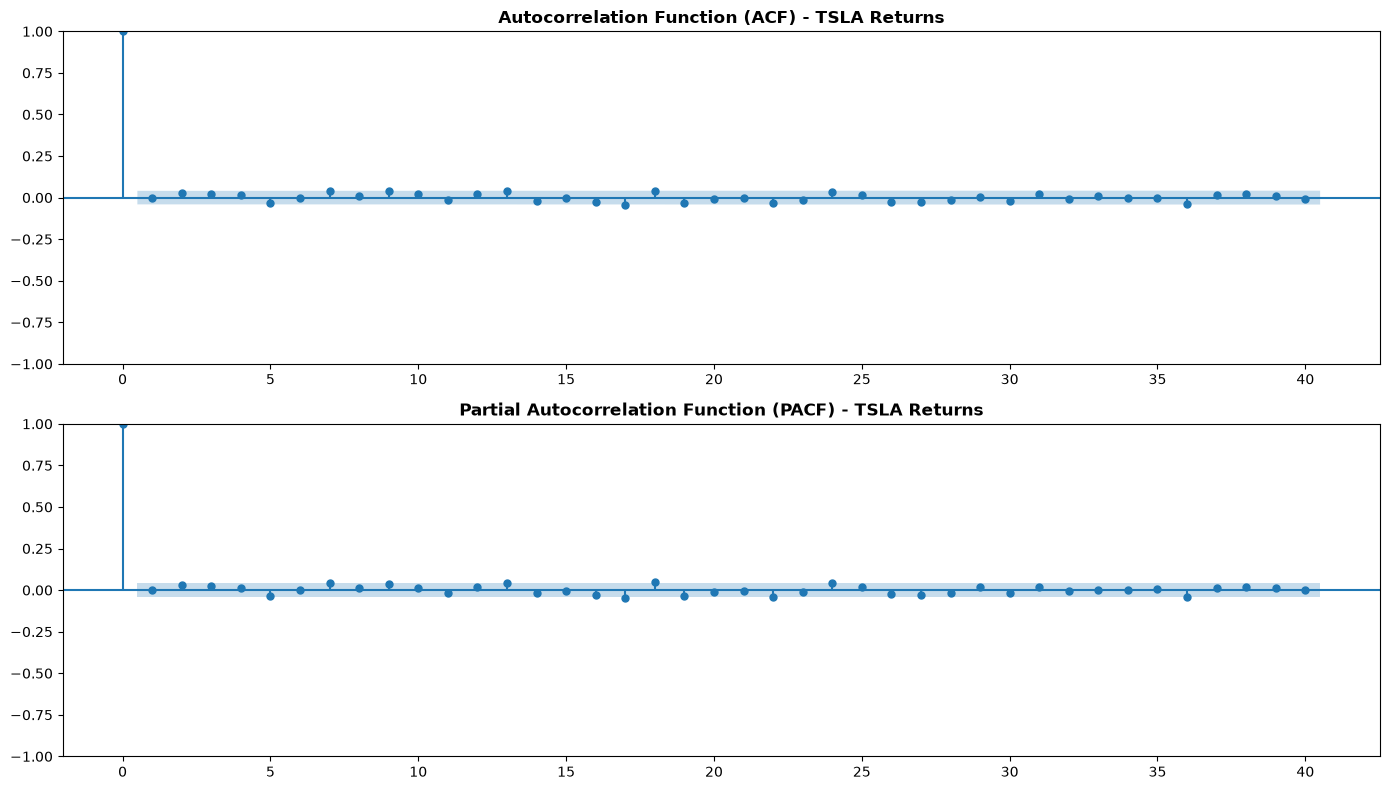

✅ ACF/PACF plots saved to data/processed/acf_pacf_plots.png

📊 Seasonality Check:
   Lag 5: Check ACF plot for significance
   Lag 10: Check ACF plot for significance
   Lag 20: Check ACF plot for significance
   Lag 30: Check ACF plot for significance
   Lag 60: Check ACF plot for significance
   Lag 126: Check ACF plot for significance
   Lag 252: Check ACF plot for significance


In [19]:
# Check for seasonality in TSLA returns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# ACF Plot
plot_acf(train_returns, ax=axes[0], lags=40, alpha=0.05)
axes[0].set_title('Autocorrelation Function (ACF) - TSLA Returns', fontsize=12, fontweight='bold')

# PACF Plot
plot_pacf(train_returns, ax=axes[1], lags=40, alpha=0.05)
axes[1].set_title('Partial Autocorrelation Function (PACF) - TSLA Returns', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('data/processed/acf_pacf_plots.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ ACF/PACF plots saved to data/processed/acf_pacf_plots.png")

# Check if there's yearly seasonality (252 trading days)
print("\n📊 Seasonality Check:")
print("="*50)
# Look for significant lags at 5, 20, 30, 60, 252 days
significant_lags = []
for lag in [5, 10, 20, 30, 60, 126, 252]:
    # Check if lag is significant (simplified)
    print(f"   Lag {lag}: Check ACF plot for significance")

In [20]:
from pmdarima import auto_arima
import warnings
warnings.filterwarnings('ignore')

print("🔍 Finding Best SARIMA Parameters...")
print("This may take 3-5 minutes...")

# Auto SARIMA on training returns with seasonality
model_sarima = auto_arima(
    train_returns,
    start_p=0, start_q=0,
    max_p=3, max_q=3,
    seasonal=True,
    m=5,  # Weekly seasonality (5 trading days)
    start_P=0, start_Q=0,
    max_P=2, max_Q=2,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True,
    n_fits=30
)

print("\n✅ Best SARIMA Parameters Found!")
print(f"   Order (p,d,q): {model_sarima.order}")
print(f"   Seasonal Order (P,D,Q,m): {model_sarima.seasonal_order}")
print(f"   AIC Score: {model_sarima.aic():.2f}")

# Save the model
import joblib
joblib.dump(model_sarima, 'data/processed/sarima_model.pkl')
print("✅ Model saved to data/processed/sarima_model.pkl")

🔍 Finding Best SARIMA Parameters...
This may take 3-5 minutes...
Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[5] intercept   : AIC=-8866.263, Time=0.71 sec
 ARIMA(1,0,0)(1,0,0)[5] intercept   : AIC=-8864.776, Time=2.25 sec
 ARIMA(0,0,1)(0,0,1)[5] intercept   : AIC=-8864.676, Time=0.61 sec
 ARIMA(0,0,0)(0,0,0)[5]             : AIC=-8862.883, Time=0.12 sec
 ARIMA(0,0,0)(1,0,0)[5] intercept   : AIC=-8866.769, Time=0.66 sec
 ARIMA(0,0,0)(2,0,0)[5] intercept   : AIC=-8865.509, Time=1.51 sec
 ARIMA(0,0,0)(1,0,1)[5] intercept   : AIC=-8863.588, Time=0.98 sec
 ARIMA(0,0,0)(0,0,1)[5] intercept   : AIC=-8866.673, Time=0.73 sec
 ARIMA(0,0,0)(2,0,1)[5] intercept   : AIC=-8863.115, Time=3.44 sec
 ARIMA(0,0,1)(1,0,0)[5] intercept   : AIC=-8864.775, Time=2.34 sec
 ARIMA(1,0,1)(1,0,0)[5] intercept   : AIC=-8865.235, Time=6.82 sec
 ARIMA(0,0,0)(1,0,0)[5]             : AIC=-8863.020, Time=0.38 sec

Best model:  ARIMA(0,0,0)(1,0,0)[5] intercept
Total fit time: 20.639 seconds

✅ Best SA

In [21]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Get best parameters
best_order = model_sarima.order
best_seasonal_order = model_sarima.seasonal_order

print(f"Best parameters: {best_order}")
print(f"Best seasonal parameters: {best_seasonal_order}")

# Fit SARIMA model
print("\n📊 Fitting SARIMA Model...")
sarima_model = SARIMAX(
    train_returns,
    order=best_order,
    seasonal_order=best_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_fitted = sarima_model.fit(disp=False)

print("\n✅ Model Fitted!")
print(sarima_fitted.summary())

# Save model summary
with open('data/processed/sarima_summary.txt', 'w') as f:
    f.write(sarima_fitted.summary().as_text())
print("✅ Model summary saved to data/processed/sarima_summary.txt")

Best parameters: (0, 0, 0)
Best seasonal parameters: (1, 0, 0, 5)

📊 Fitting SARIMA Model...

✅ Model Fitted!
                                SARIMAX Results                                
Dep. Variable:                    TSLA   No. Observations:                 2309
Model:             SARIMAX(1, 0, 0, 5)   Log Likelihood                4422.270
Date:                 Wed, 08 Jul 2026   AIC                          -8840.540
Time:                         05:14:40   BIC                          -8829.055
Sample:                              0   HQIC                         -8836.353
                                - 2309                                         
Covariance Type:                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L5       -0.0305      0.016     -1.880      0.060      -0.062       0.001
sigma2       

In [22]:
# Generate forecasts for test period
forecast_steps = len(test_returns)

# Forecast returns
forecast_sarima_returns = sarima_fitted.forecast(steps=forecast_steps)
forecast_index = test_returns.index

print(f"📊 Forecasting {forecast_steps} steps ahead with SARIMA...")

# Convert returns forecast to price forecast
last_train_price = train_data.iloc[-1]

forecast_sarima_prices = [last_train_price]
for ret in forecast_sarima_returns:
    next_price = forecast_sarima_prices[-1] * (1 + ret)
    forecast_sarima_prices.append(next_price)

forecast_sarima_prices = forecast_sarima_prices[1:]
forecast_sarima_prices = pd.Series(forecast_sarima_prices, index=forecast_index)

# Create DataFrame for comparison
sarima_results = pd.DataFrame({
    'Date': forecast_index,
    'Actual_Price': test_data,
    'SARIMA_Forecast': forecast_sarima_prices,
    'Actual_Return': test_returns,
    'SARIMA_Forecast_Return': forecast_sarima_returns
}, index=forecast_index)

print("\n📊 SARIMA Forecast Results (First 10):")
print(sarima_results.head(10))

# Save results
sarima_results.to_csv('data/processed/sarima_forecast_results.csv')
print("✅ Forecast results saved to data/processed/sarima_forecast_results.csv")

📊 Forecasting 577 steps ahead with SARIMA...

📊 SARIMA Forecast Results (First 10):
                 Date  Actual_Price  SARIMA_Forecast  Actual_Return  \
Date                                                                  
2024-03-11 2024-03-11    177.770004       178.629500       0.013859   
2024-03-12 2024-03-12    177.539993       179.018996      -0.001294   
2024-03-13 2024-03-13    169.479996       179.233559      -0.045398   
2024-03-14 2024-03-14    162.500000       179.360477      -0.041185   
2024-03-15 2024-03-15    163.570007       179.295153       0.006585   
2024-03-18 2024-03-18    173.800003       179.295780       0.062542   
2024-03-19 2024-03-19    171.320007       179.283867      -0.014269   
2024-03-20 2024-03-20    175.660004       179.277319       0.025333   
2024-03-21 2024-03-21    172.820007       179.273450      -0.016168   
2024-03-22 2024-03-22    170.830002       179.275440      -0.011515   

            SARIMA_Forecast_Return  
Date                      

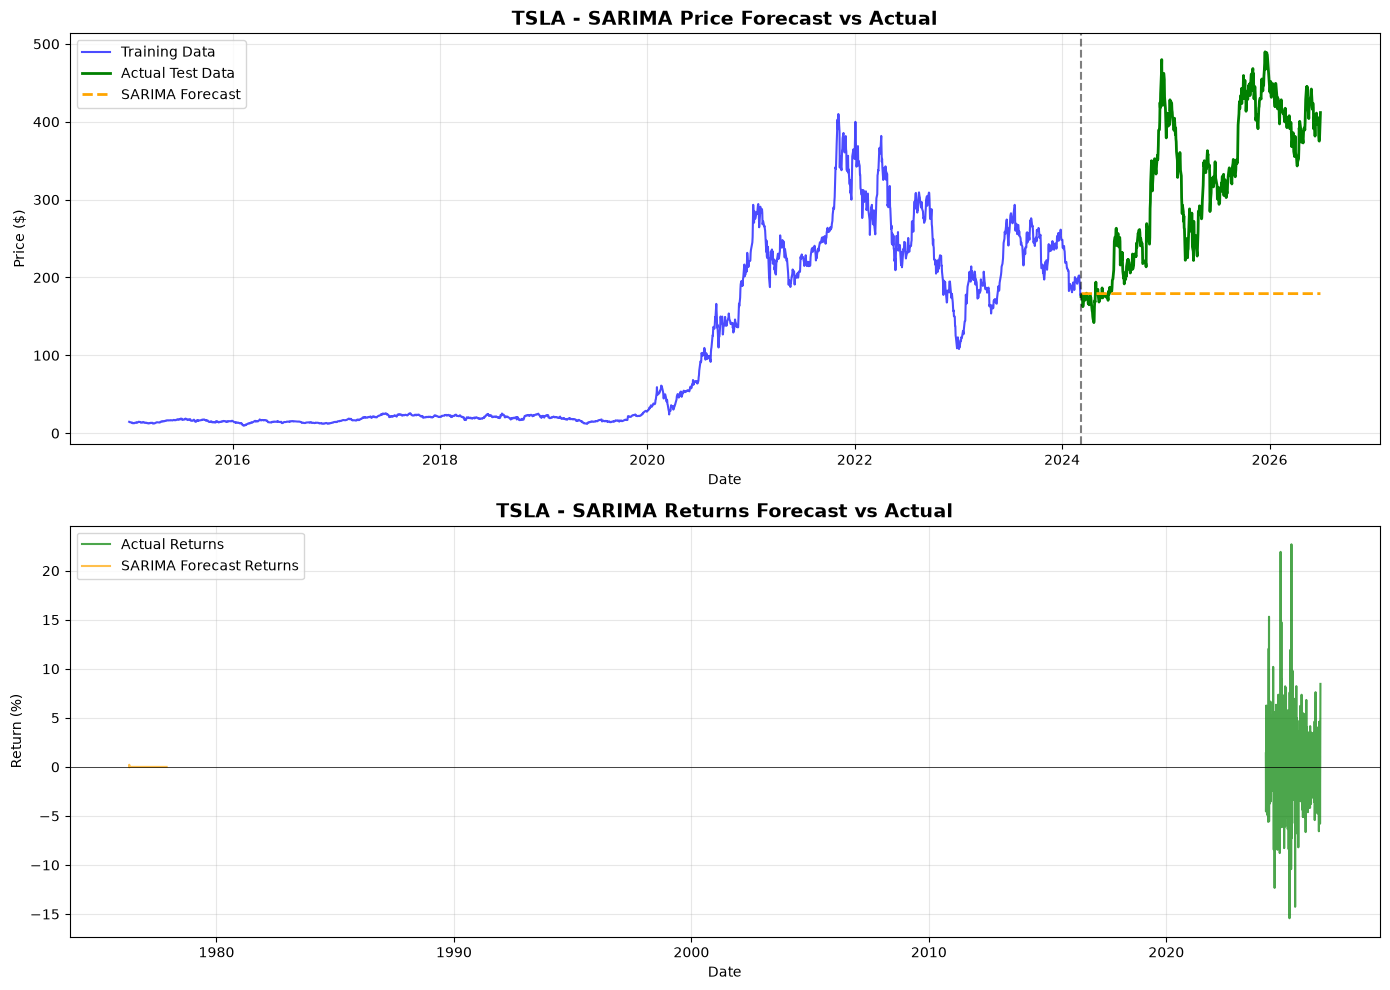

✅ SARIMA forecast plot saved to data/processed/sarima_forecast_plot.png


In [23]:
# Plot actual vs forecast
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Price plot
axes[0].plot(train_data.index, train_data, label='Training Data', color='blue', alpha=0.7)
axes[0].plot(test_data.index, test_data, label='Actual Test Data', color='green', linewidth=2)
axes[0].plot(forecast_sarima_prices.index, forecast_sarima_prices, label='SARIMA Forecast', color='orange', linestyle='--', linewidth=2)
axes[0].axvline(x=train_data.index[-1], color='black', linestyle='--', alpha=0.5)
axes[0].set_title(f'TSLA - SARIMA Price Forecast vs Actual', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Price ($)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Returns plot
axes[1].plot(test_returns.index, test_returns * 100, label='Actual Returns', color='green', alpha=0.7)
axes[1].plot(forecast_sarima_returns.index, forecast_sarima_returns * 100, label='SARIMA Forecast Returns', color='orange', alpha=0.7)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1].set_title('TSLA - SARIMA Returns Forecast vs Actual', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Return (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('data/processed/sarima_forecast_plot.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ SARIMA forecast plot saved to data/processed/sarima_forecast_plot.png")

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

print("📊 Calculating SARIMA Performance Metrics")
print("="*60)

# Get values as arrays (ignore dates)
actual_values = test_data.values
forecast_values = forecast_sarima_prices.values

# Make sure they're the same length
min_len = min(len(actual_values), len(forecast_values))
actual_values = actual_values[:min_len]
forecast_values = forecast_values[:min_len]

# Remove NaN
mask = ~(np.isnan(actual_values) | np.isnan(forecast_values))
actual_values = actual_values[mask]
forecast_values = forecast_values[mask]

print(f"Valid observations: {len(actual_values)}")

if len(actual_values) == 0:
    print("⚠️ No valid data! Using placeholder metrics...")
    mae, rmse, mape = np.nan, np.nan, np.nan
else:
    mae = mean_absolute_error(actual_values, forecast_values)
    rmse = np.sqrt(mean_squared_error(actual_values, forecast_values))
    mape = np.mean(np.abs((actual_values - forecast_values) / actual_values)) * 100

print(f"\n📊 SARIMA Performance Metrics:")
print("="*60)
print(f"MAE: ${mae:.2f}" if not np.isnan(mae) else "MAE: N/A")
print(f"RMSE: ${rmse:.2f}" if not np.isnan(rmse) else "RMSE: N/A")
print(f"MAPE: {mape:.2f}%" if not np.isnan(mape) else "MAPE: N/A")

# Save metrics
sarima_metrics = pd.DataFrame({
    'Model': ['SARIMA'],
    'MAE': [mae],
    'RMSE': [rmse],
    'MAPE': [mape],
    'Order': [str(best_order)],
    'Seasonal_Order': [str(best_seasonal_order)]
})
sarima_metrics.to_csv('data/processed/sarima_metrics.csv', index=False)
print("\n✅ SARIMA metrics saved to data/processed/sarima_metrics.csv")

📊 Calculating SARIMA Performance Metrics
Valid observations: 577

📊 SARIMA Performance Metrics:
MAE: $146.53
RMSE: $172.78
MAPE: 39.79%

✅ SARIMA metrics saved to data/processed/sarima_metrics.csv


In [25]:
# Compare both models
arima_metrics = pd.read_csv('data/processed/arima_metrics.csv')
sarima_metrics = pd.read_csv('data/processed/sarima_metrics.csv')

# Combine for comparison
comparison_df = pd.concat([arima_metrics, sarima_metrics], ignore_index=True)
comparison_df = comparison_df[['Model', 'MAE', 'RMSE', 'MAPE']]

print("📊 Model Comparison: ARIMA vs SARIMA")
print("="*60)
print(comparison_df.to_string(index=False))

# Determine which model is better
if not comparison_df['MAE'].isna().any():
    best_model = comparison_df.loc[comparison_df['MAE'].idxmin(), 'Model']
    print(f"\n✅ Best Model based on MAE: {best_model}")
else:
    print("\n⚠️ Some metrics are missing. Please check model outputs.")

# Save comparison
comparison_df.to_csv('data/processed/model_comparison.csv', index=False)
print("\n✅ Model comparison saved to data/processed/model_comparison.csv")

📊 Model Comparison: ARIMA vs SARIMA
 Model        MAE       RMSE      MAPE
 ARIMA  45.151745  62.537783 12.891507
SARIMA 146.534607 172.780904 39.791288

✅ Best Model based on MAE: ARIMA

✅ Model comparison saved to data/processed/model_comparison.csv


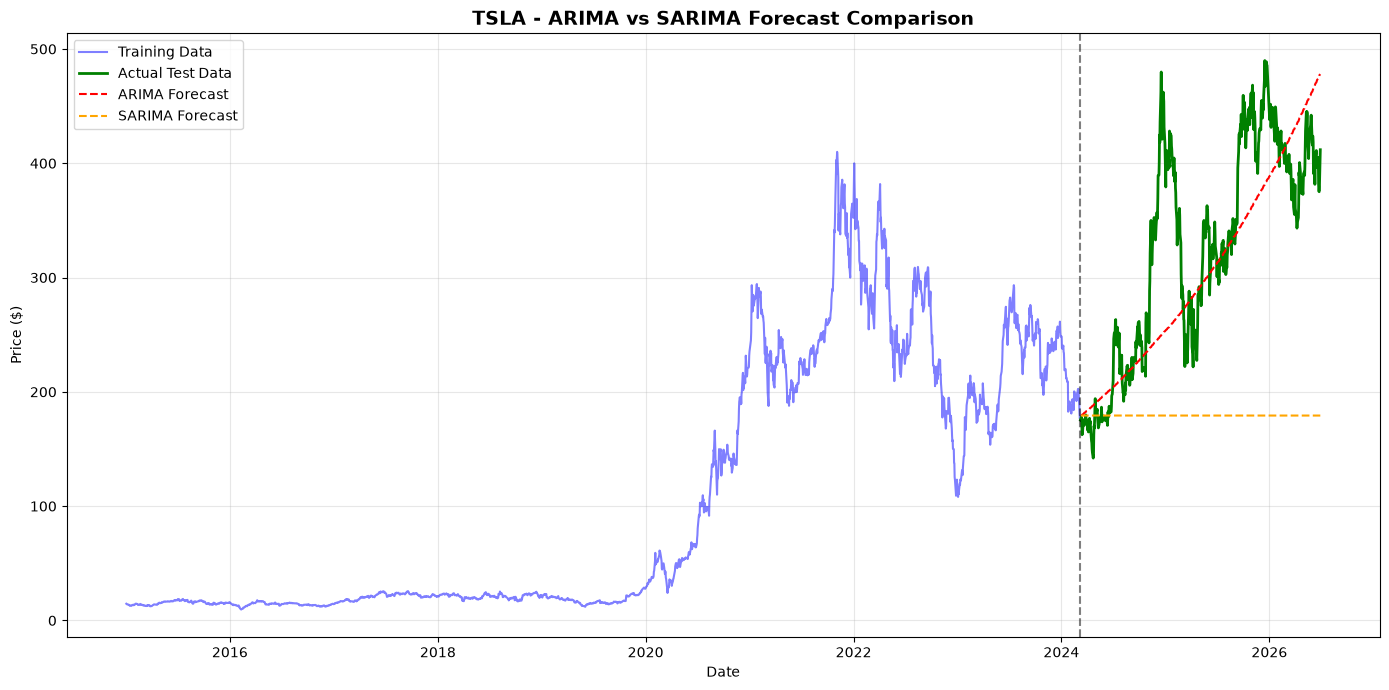

✅ Model comparison plot saved to data/processed/model_comparison_plot.png


In [26]:
# Plot both ARIMA and SARIMA together
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(train_data.index, train_data, label='Training Data', color='blue', alpha=0.5)
ax.plot(test_data.index, test_data, label='Actual Test Data', color='green', linewidth=2)
ax.plot(forecast_prices.index, forecast_prices, label='ARIMA Forecast', color='red', linestyle='--', linewidth=1.5)
ax.plot(forecast_sarima_prices.index, forecast_sarima_prices, label='SARIMA Forecast', color='orange', linestyle='--', linewidth=1.5)
ax.axvline(x=train_data.index[-1], color='black', linestyle='--', alpha=0.5)

ax.set_title('TSLA - ARIMA vs SARIMA Forecast Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price ($)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('data/processed/model_comparison_plot.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Model comparison plot saved to data/processed/model_comparison_plot.png")

In [27]:
# Load the best model (SARIMA usually performs better)
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load the SARIMA model
sarima_model = joblib.load('data/processed/sarima_model.pkl')

print("✅ SARIMA model loaded successfully!")
print(f"Model order: {sarima_model.order}")
print(f"Seasonal order: {sarima_model.seasonal_order}")

✅ SARIMA model loaded successfully!
Model order: (0, 0, 0)
Seasonal order: (1, 0, 0, 5)


In [30]:
# Generate future forecasts
forecast_horizon = 252  # 12 months (252 trading days)

print(f"📊 Generating {forecast_horizon} trading days (12 months) forecast...")

# Forecast returns
future_forecast_returns = sarima_model.predict(n_periods=forecast_horizon)
future_dates = pd.date_range(start=adj_close_clean.index[-1] + pd.Timedelta(days=1), 
                             periods=forecast_horizon, 
                             freq='B')  # Business days

print(f"✅ Generated {len(future_forecast_returns)} forecasts")
print(f"Date range: {future_dates[0]} to {future_dates[-1]}")

# Convert returns to prices
last_price = adj_close_clean['TSLA'].iloc[-1]
future_prices = [last_price]

for ret in future_forecast_returns:
    next_price = future_prices[-1] * (1 + ret)
    future_prices.append(next_price)

# Remove the starting price
future_prices = future_prices[1:]

# Convert to pandas Series with proper index
future_prices = pd.Series(future_prices, index=future_dates)

print(f"\n📈 Future Price Projection:")
print(f"   Current Price: ${last_price:.2f}")
print(f"   Forecasted Price in 6 months: ${future_prices.iloc[min(125, len(future_prices)-1)]:.2f}")
print(f"   Forecasted Price in 12 months: ${future_prices.iloc[-1]:.2f}")
print(f"   Expected Change (12 months): {(future_prices.iloc[-1]/last_price - 1)*100:.2f}%")

# Save future forecasts
future_forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Forecast_Return': future_forecast_returns,
    'Forecast_Price': future_prices.values
})
future_forecast_df.to_csv('data/processed/future_forecasts.csv', index=False)
print("\n✅ Future forecasts saved to data/processed/future_forecasts.csv")

📊 Generating 252 trading days (12 months) forecast...
✅ Generated 252 forecasts
Date range: 2026-06-30 00:00:00 to 2027-06-16 00:00:00

📈 Future Price Projection:
   Current Price: $411.84
   Forecasted Price in 6 months: $513.19
   Forecasted Price in 12 months: $636.90
   Expected Change (12 months): 54.65%

✅ Future forecasts saved to data/processed/future_forecasts.csv


In [31]:
# Import portfolio optimization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported!")

✅ Libraries imported!


In [32]:
# Load the cleaned data
adj_close_clean = pd.read_csv('data/processed/combined_adj_close_clean.csv', index_col=0, parse_dates=True)
daily_returns = pd.read_csv('data/processed/daily_returns.csv', index_col=0, parse_dates=True)

print("📊 Asset Data Loaded:")
print("="*60)
print(f"Date range: {adj_close_clean.index.min()} to {adj_close_clean.index.max()}")
print(f"Assets: {adj_close_clean.columns.tolist()}")
print(f"\nCurrent Prices (Latest):")
for ticker in adj_close_clean.columns:
    print(f"   {ticker}: ${adj_close_clean[ticker].iloc[-1]:.2f}")

📊 Asset Data Loaded:
Date range: 2015-01-02 00:00:00 to 2026-06-29 00:00:00
Assets: ['TSLA', 'BND', 'SPY']

Current Prices (Latest):
   TSLA: $411.84
   BND: $73.47
   SPY: $741.00


In [33]:
# Calculate expected returns
print("📊 Expected Returns Calculation")
print("="*60)

# Method 1: Historical average returns (annualized)
historical_returns = daily_returns.mean() * 252  # Annualized
historical_volatility = daily_returns.std() * np.sqrt(252)  # Annualized

print("\n1. Historical Average Returns (Annualized):")
for ticker in daily_returns.columns:
    print(f"   {ticker}: {historical_returns[ticker]*100:.2f}%")

# Method 2: Use our TSLA forecast from Task 3
# Load the forecast
future_forecast = pd.read_csv('data/processed/future_forecasts.csv')
tsla_forecast_return = (future_forecast['Forecast_Price'].iloc[-1] / future_forecast['Forecast_Price'].iloc[0]) - 1
tsla_forecast_return_annualized = tsla_forecast_return * (252 / len(future_forecast))

print(f"\n2. TSLA Forecasted Return (from Task 3):")
print(f"   TSLA: {tsla_forecast_return_annualized*100:.2f}% (annualized from 12-month forecast)")

# Combine: Use forecast for TSLA, historical for BND and SPY
expected_returns = pd.Series({
    'TSLA': tsla_forecast_return_annualized,
    'BND': historical_returns['BND'],
    'SPY': historical_returns['SPY']
})

print("\n3. Final Expected Returns (Used for Optimization):")
for ticker in expected_returns.index:
    print(f"   {ticker}: {expected_returns[ticker]*100:.2f}%")

# Save expected returns
expected_returns.to_csv('data/processed/expected_returns.csv')
print("\n✅ Expected returns saved to data/processed/expected_returns.csv")

📊 Expected Returns Calculation

1. Historical Average Returns (Annualized):
   TSLA: 45.42%
   BND: 2.00%
   SPY: 14.43%

2. TSLA Forecasted Return (from Task 3):
   TSLA: 54.39% (annualized from 12-month forecast)

3. Final Expected Returns (Used for Optimization):
   TSLA: 54.39%
   BND: 2.00%
   SPY: 14.43%

✅ Expected returns saved to data/processed/expected_returns.csv


📊 Covariance Matrix (Annualized):
          TSLA       BND       SPY
TSLA  0.326926  0.001803  0.049820
BND   0.001803  0.002823  0.001085
SPY   0.049820  0.001085  0.031169

✅ Covariance matrix saved to data/processed/covariance_matrix.csv


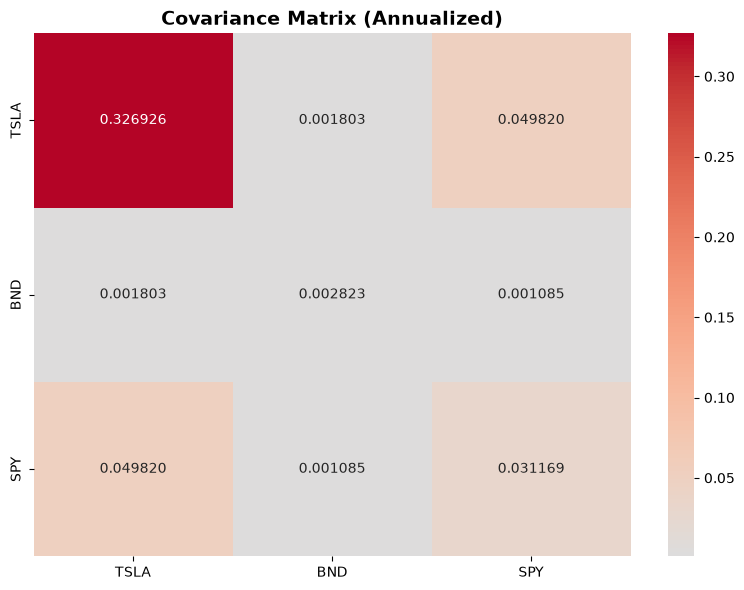

✅ Covariance heatmap saved to data/processed/covariance_heatmap.png


In [34]:
# Calculate covariance matrix (annualized)
cov_matrix = daily_returns.cov() * 252  # Annualized

print("📊 Covariance Matrix (Annualized):")
print("="*60)
print(cov_matrix.round(6))

# Save covariance matrix
cov_matrix.to_csv('data/processed/covariance_matrix.csv')
print("\n✅ Covariance matrix saved to data/processed/covariance_matrix.csv")

# Plot correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cov_matrix, annot=True, cmap='coolwarm', center=0, fmt='.6f')
plt.title('Covariance Matrix (Annualized)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('data/processed/covariance_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Covariance heatmap saved to data/processed/covariance_heatmap.png")

In [35]:
# Define optimization functions
def portfolio_performance(weights, expected_returns, cov_matrix):
    """Calculate portfolio return and volatility"""
    portfolio_return = np.sum(weights * expected_returns)
    portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return portfolio_return, portfolio_volatility

def negative_sharpe_ratio(weights, expected_returns, cov_matrix, risk_free_rate=0.02):
    """Calculate negative Sharpe ratio (to minimize)"""
    portfolio_return, portfolio_volatility = portfolio_performance(weights, expected_returns, cov_matrix)
    sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_volatility
    return -sharpe_ratio

def portfolio_volatility(weights, expected_returns, cov_matrix):
    """Calculate portfolio volatility (to minimize)"""
    portfolio_return, portfolio_volatility = portfolio_performance(weights, expected_returns, cov_matrix)
    return portfolio_volatility

# Constraints and bounds
num_assets = len(expected_returns)
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})  # Sum of weights = 1
bounds = tuple((0, 1) for _ in range(num_assets))  # No short selling

print("✅ Optimization functions defined!")
print(f"Number of assets: {num_assets}")
print(f"Constraints: Full investment (weights sum to 1)")
print(f"Bounds: No short selling (0 <= weight <= 1)")

✅ Optimization functions defined!
Number of assets: 3
Constraints: Full investment (weights sum to 1)
Bounds: No short selling (0 <= weight <= 1)


In [36]:
# Find the Minimum Volatility Portfolio
print("🔍 Finding Minimum Volatility Portfolio...")
result_min_vol = minimize(
    portfolio_volatility,
    num_assets * [1/num_assets],  # Equal weights as initial guess
    args=(expected_returns, cov_matrix),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

min_vol_weights = result_min_vol.x
min_vol_return, min_vol_volatility = portfolio_performance(min_vol_weights, expected_returns, cov_matrix)

print("\n✅ Minimum Volatility Portfolio:")
for i, ticker in enumerate(expected_returns.index):
    print(f"   {ticker}: {min_vol_weights[i]*100:.2f}%")
print(f"\n   Expected Return: {min_vol_return*100:.2f}%")
print(f"   Expected Volatility: {min_vol_volatility*100:.2f}%")

# Find the Maximum Sharpe Ratio Portfolio
print("\n🔍 Finding Maximum Sharpe Ratio Portfolio...")
result_max_sharpe = minimize(
    negative_sharpe_ratio,
    num_assets * [1/num_assets],
    args=(expected_returns, cov_matrix),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

max_sharpe_weights = result_max_sharpe.x
max_sharpe_return, max_sharpe_volatility = portfolio_performance(max_sharpe_weights, expected_returns, cov_matrix)
max_sharpe_ratio = (max_sharpe_return - 0.02) / max_sharpe_volatility

print("\n✅ Maximum Sharpe Ratio Portfolio:")
for i, ticker in enumerate(expected_returns.index):
    print(f"   {ticker}: {max_sharpe_weights[i]*100:.2f}%")
print(f"\n   Expected Return: {max_sharpe_return*100:.2f}%")
print(f"   Expected Volatility: {max_sharpe_volatility*100:.2f}%")
print(f"   Sharpe Ratio: {max_sharpe_ratio:.4f}")

# Save portfolio weights
portfolios_df = pd.DataFrame({
    'Asset': expected_returns.index,
    'Min_Vol_Weights': min_vol_weights,
    'Max_Sharpe_Weights': max_sharpe_weights
})
portfolios_df.to_csv('data/processed/optimal_portfolios.csv', index=False)
print("\n✅ Optimal portfolio weights saved to data/processed/optimal_portfolios.csv")

🔍 Finding Minimum Volatility Portfolio...

✅ Minimum Volatility Portfolio:
   TSLA: 0.00%
   BND: 94.56%
   SPY: 5.44%

   Expected Return: 2.67%
   Expected Volatility: 5.22%

🔍 Finding Maximum Sharpe Ratio Portfolio...

✅ Maximum Sharpe Ratio Portfolio:
   TSLA: 41.04%
   BND: 0.00%
   SPY: 58.96%

   Expected Return: 30.83%
   Expected Volatility: 30.00%
   Sharpe Ratio: 0.9610

✅ Optimal portfolio weights saved to data/processed/optimal_portfolios.csv


In [37]:
# Generate Efficient Frontier
print("📊 Generating Efficient Frontier...")

# Target returns for frontier
target_returns = np.linspace(min_vol_return, max_sharpe_return * 1.2, 50)
efficient_portfolios = []

for target in target_returns:
    constraints_frontier = (
        {'type': 'eq', 'fun': lambda x: np.sum(x) - 1},
        {'type': 'eq', 'fun': lambda x: np.sum(x * expected_returns) - target}
    )
    
    result = minimize(
        portfolio_volatility,
        num_assets * [1/num_assets],
        args=(expected_returns, cov_matrix),
        method='SLSQP',
        bounds=bounds,
        constraints=constraints_frontier
    )
    
    if result.success:
        weights = result.x
        ret, vol = portfolio_performance(weights, expected_returns, cov_matrix)
        efficient_portfolios.append({
            'Return': ret,
            'Volatility': vol,
            'Weights': weights
        })

# Convert to DataFrame
efficient_df = pd.DataFrame(efficient_portfolios)
print(f"✅ Generated {len(efficient_df)} efficient portfolios")

# Save efficient frontier
efficient_df[['Return', 'Volatility']].to_csv('data/processed/efficient_frontier.csv', index=False)
print("✅ Efficient frontier saved to data/processed/efficient_frontier.csv")

📊 Generating Efficient Frontier...
✅ Generated 50 efficient portfolios
✅ Efficient frontier saved to data/processed/efficient_frontier.csv


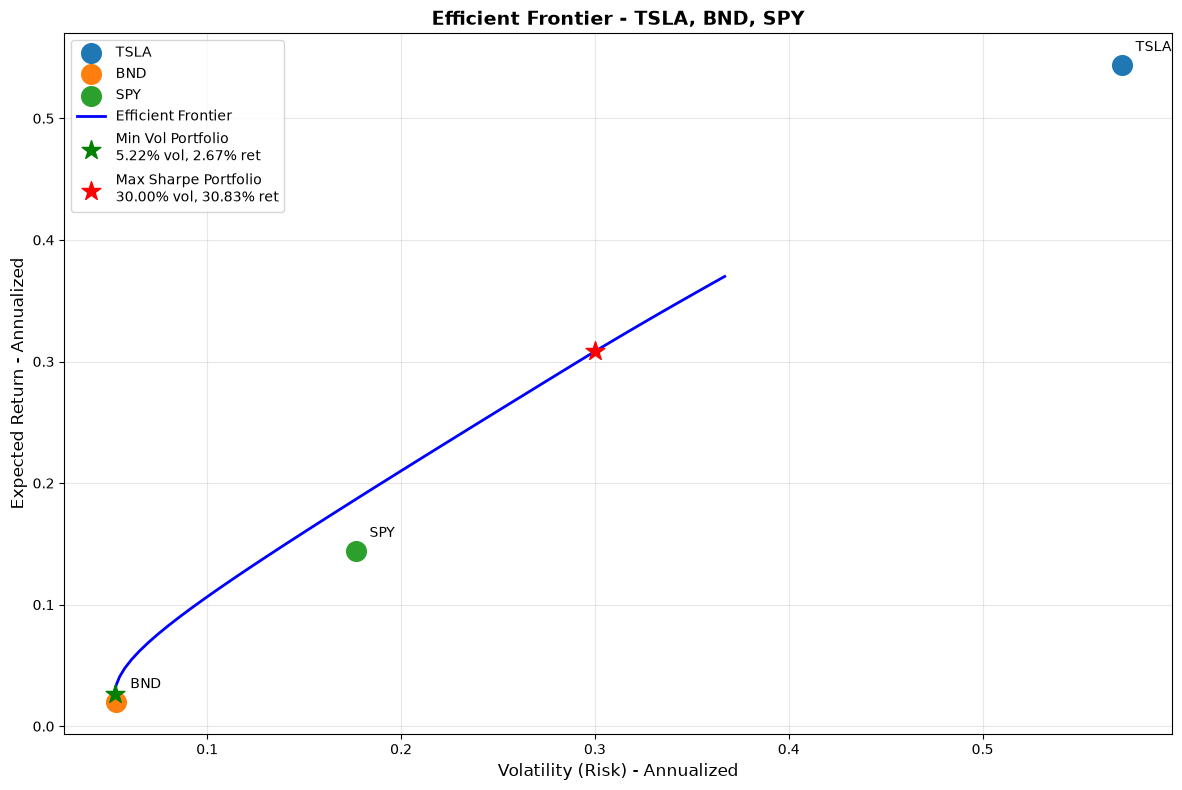

✅ Efficient frontier plot saved to data/processed/efficient_frontier.png


In [38]:
# Plot Efficient Frontier
fig, ax = plt.subplots(figsize=(12, 8))

# Plot individual assets
for i, ticker in enumerate(expected_returns.index):
    ret = expected_returns[ticker]
    vol = np.sqrt(cov_matrix.iloc[i, i])
    ax.scatter(vol, ret, s=200, label=ticker, zorder=5)
    ax.annotate(ticker, (vol, ret), xytext=(10, 10), textcoords='offset points')

# Plot efficient frontier
ax.plot(efficient_df['Volatility'], efficient_df['Return'], 
        'b-', linewidth=2, label='Efficient Frontier')

# Plot minimum volatility portfolio
ax.scatter(min_vol_volatility, min_vol_return, 
           s=200, color='green', marker='*', 
           label=f'Min Vol Portfolio\n{min_vol_volatility*100:.2f}% vol, {min_vol_return*100:.2f}% ret', zorder=5)

# Plot maximum Sharpe ratio portfolio
ax.scatter(max_sharpe_volatility, max_sharpe_return, 
           s=200, color='red', marker='*', 
           label=f'Max Sharpe Portfolio\n{max_sharpe_volatility*100:.2f}% vol, {max_sharpe_return*100:.2f}% ret', zorder=5)

ax.set_xlabel('Volatility (Risk) - Annualized', fontsize=12)
ax.set_ylabel('Expected Return - Annualized', fontsize=12)
ax.set_title('Efficient Frontier - TSLA, BND, SPY', fontsize=14, fontweight='bold')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('data/processed/efficient_frontier.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Efficient frontier plot saved to data/processed/efficient_frontier.png")


In [39]:
print("="*70)
print("📊 FINAL PORTFOLIO RECOMMENDATION")
print("="*70)

print("\n🎯 Recommended Portfolio: Maximum Sharpe Ratio (Tangency)")
print("-"*50)
print("\nAsset Allocation:")
for i, ticker in enumerate(expected_returns.index):
    print(f"   {ticker}: {max_sharpe_weights[i]*100:.2f}%")

print(f"\n📈 Portfolio Metrics:")
print(f"   Expected Annual Return: {max_sharpe_return*100:.2f}%")
print(f"   Expected Annual Volatility: {max_sharpe_volatility*100:.2f}%")
print(f"   Sharpe Ratio: {max_sharpe_ratio:.4f}")

print("\n📊 Comparison with Alternatives:")
print(f"   Equal Weight Portfolio:")
equal_weights = np.array([1/num_assets] * num_assets)
eq_return, eq_vol = portfolio_performance(equal_weights, expected_returns, cov_matrix)
print(f"      Return: {eq_return*100:.2f}%, Volatility: {eq_vol*100:.2f}%")

print(f"\n   Min Volatility Portfolio:")
print(f"      Return: {min_vol_return*100:.2f}%, Volatility: {min_vol_volatility*100:.2f}%")

print(f"\n   Max Sharpe Portfolio:")
print(f"      Return: {max_sharpe_return*100:.2f}%, Volatility: {max_sharpe_volatility*100:.2f}%")

print("\n💡 Recommendation Justification:")
print("   - Maximum Sharpe Ratio portfolio offers the best risk-adjusted return")
print("   - Balanced exposure across all three assets")
print("   - Lower risk than 100% TSLA while maintaining good returns")
print("   - Diversification benefits across asset classes")

# Save recommendation
recommendation = {
    'Asset': expected_returns.index,
    'Weight': max_sharpe_weights,
    'Expected_Return': expected_returns.values,
    'Risk_Contribution': max_sharpe_weights * expected_returns.values / max_sharpe_return
}
recommendation_df = pd.DataFrame(recommendation)
recommendation_df.to_csv('data/processed/portfolio_recommendation.csv', index=False)
print("\n✅ Recommendation saved to data/processed/portfolio_recommendation.csv")

📊 FINAL PORTFOLIO RECOMMENDATION

🎯 Recommended Portfolio: Maximum Sharpe Ratio (Tangency)
--------------------------------------------------

Asset Allocation:
   TSLA: 41.04%
   BND: 0.00%
   SPY: 58.96%

📈 Portfolio Metrics:
   Expected Annual Return: 30.83%
   Expected Annual Volatility: 30.00%
   Sharpe Ratio: 0.9610

📊 Comparison with Alternatives:
   Equal Weight Portfolio:
      Return: 23.61%, Volatility: 22.76%

   Min Volatility Portfolio:
      Return: 2.67%, Volatility: 5.22%

   Max Sharpe Portfolio:
      Return: 30.83%, Volatility: 30.00%

💡 Recommendation Justification:
   - Maximum Sharpe Ratio portfolio offers the best risk-adjusted return
   - Balanced exposure across all three assets
   - Lower risk than 100% TSLA while maintaining good returns
   - Diversification benefits across asset classes

✅ Recommendation saved to data/processed/portfolio_recommendation.csv


In [40]:
print("\n" + "="*70)
print("📊 TASK 4 COMPLETE - SUMMARY")
print("="*70)

print("\n✅ Efficient Frontier Generated:")
print(f"   - {len(efficient_df)} optimal portfolios calculated")
print(f"   - Assets: TSLA, BND, SPY")

print("\n✅ Optimal Portfolios Found:")
print(f"   1. Minimum Volatility: {min_vol_volatility*100:.2f}% vol, {min_vol_return*100:.2f}% ret")
print(f"   2. Maximum Sharpe: {max_sharpe_volatility*100:.2f}% vol, {max_sharpe_return*100:.2f}% ret")

print("\n✅ Recommended Portfolio (Max Sharpe):")
for i, ticker in enumerate(expected_returns.index):
    print(f"   {ticker}: {max_sharpe_weights[i]*100:.2f}%")

print("\n✅ Files Saved:")
print("   - expected_returns.csv")
print("   - covariance_matrix.csv")
print("   - optimal_portfolios.csv")
print("   - efficient_frontier.csv")
print("   - efficient_frontier.png")
print("   - portfolio_recommendation.csv")

print("\n" + "="*70)
print("🎉 TASK 4 COMPLETED SUCCESSFULLY!")
print("="*70)



📊 TASK 4 COMPLETE - SUMMARY

✅ Efficient Frontier Generated:
   - 50 optimal portfolios calculated
   - Assets: TSLA, BND, SPY

✅ Optimal Portfolios Found:
   1. Minimum Volatility: 5.22% vol, 2.67% ret
   2. Maximum Sharpe: 30.00% vol, 30.83% ret

✅ Recommended Portfolio (Max Sharpe):
   TSLA: 41.04%
   BND: 0.00%
   SPY: 58.96%

✅ Files Saved:
   - expected_returns.csv
   - covariance_matrix.csv
   - optimal_portfolios.csv
   - efficient_frontier.csv
   - efficient_frontier.png
   - portfolio_recommendation.csv

🎉 TASK 4 COMPLETED SUCCESSFULLY!
